# Home Credit Default Risk — Production Notebook

**Tujuan:** Membangun sistem prediksi risiko kredit untuk membantu Home Credit Indonesia mengidentifikasi peminjam yang berisiko gagal bayar.

**Dataset:** [Home Credit Default Risk — Kaggle](https://www.kaggle.com/c/home-credit-default-risk)

---
## Alur Kerja Notebook

| # | Tahap | Deskripsi |
|---|-------|-----------|
| 1 | Setup & Import | Library dan mount Google Drive |
| 2 | Data Loading | Load semua 8 file dataset + tampilkan preview |
| 3 | EDA | Distribusi, missing values, anomali, korelasi |
| 4 | Data Cleaning | Tangani anomali, outlier, missing values |
| 5 | Feature Engineering | 50+ fitur baru berbasis domain knowledge |
| 6 | Agregasi Data Tambahan | Bureau, Previous, Installments, POS, CC |
| 7 | Encoding & Preprocessing | Label encoding, alignment |
| 8 | Modeling | LightGBM + XGBoost + Logistic Regression + Ensemble |
| 9 | Evaluasi | ROC, PR Curve, Confusion Matrix, Feature Importance |
| 10 | Business Insight | Risk Decile, Threshold Optimization, 3-Tier Policy |
| 11 | Rekomendasi Bisnis | Rekomendasi konkret & terukur |
| 12 | Save Outputs | Submission CSV, JSON summary |
| 13 | **SHAP Values** | Explainable AI — global & individual explanation |
| 14 | **Calibration Curve** | Validasi akurasi probabilitas (Brier Score, Platt Scaling) |
| 15 | **Power BI Export**  | 7 CSV tables siap import ke Power BI |
| 16 | Final Save | Semua output tersimpan |

> ⚠️ **Sebelum mulai:** Letakkan semua file CSV di folder Google Drive kamu, lalu sesuaikan `DATA_PATH` di Cell 1.


---
## Cell 1 — Setup & Import Library

In [2]:
# ── Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Library Utama ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import gc
import os
import json
from datetime import datetime
from scipy import stats
from scipy.stats import gaussian_kde

# Sklearn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, brier_score_loss,
    precision_score, recall_score, f1_score
)

# Boosting
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier

# ── Settings ───────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ── Path Data — SESUAIKAN DI SINI ─────────────────────────────
DATA_PATH = '/content/drive/MyDrive/KULIAH/Rakamin/'
# DATA_PATH = '/kaggle/input/home-credit-default-risk/'  # jika di Kaggle

print(f"Setup selesai. Data path: {DATA_PATH}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Mounted at /content/drive
Setup selesai. Data path: /content/drive/MyDrive/KULIAH/Rakamin/
Timestamp: 2026-03-30 02:09:29


---
## Cell 2 — Utility Functions

> Fungsi-fungsi pembantu yang akan digunakan di sepanjang notebook.

In [3]:
def reduce_memory(df, verbose=True):
    """Kurangi penggunaan memori dengan mengoptimalkan tipe data."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and col_type.name != 'category':
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32]:
                    if np.iinfo(dtype).min < c_min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
            else:
                if np.finfo(np.float32).min < c_min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"   Memory: {start:.1f}MB → {end:.1f}MB ({100*(start-end)/start:.0f}% saved)")
    return df


def safe_divide(a, b, fill=0):
    """Pembagian aman (hindari division by zero)."""
    return np.where(b != 0, a / b, fill)


def safe_read_csv(filename, path, nrows=None):
    """Baca CSV dengan validasi dan info ukuran file."""
    filepath = os.path.join(path, filename)
    if not os.path.exists(filepath):
        print(f"   ⚠️  {filename}: Tidak ditemukan — dilewati.")
        return None
    size_mb = os.path.getsize(filepath) / (1024*1024)
    print(f"   Loading {filename} ({size_mb:.1f} MB)...", end=" ")
    df = pd.read_csv(filepath, nrows=nrows, on_bad_lines='skip')
    df = reduce_memory(df, verbose=False)
    print(f"Shape: {df.shape}")
    return df


def missing_values_table(df):
    """Ringkasan missing values per kolom."""
    mis_val = df.isnull().sum()
    mis_pct = 100 * mis_val / len(df)
    table = pd.concat([mis_val, mis_pct], axis=1)
    table.columns = ['Missing Count', 'Missing %']
    return table[table['Missing Count'] > 0].sort_values('Missing %', ascending=False)


print("Utility functions berhasil didefinisikan.")


Utility functions berhasil didefinisikan.


---
## Cell 3 — Data Loading

Kita memiliki **8 file dataset**. Di sini kita load semua sekaligus dan langsung lihat preview-nya untuk memahami struktur data sebelum masuk ke analisis.


In [4]:
print("=" * 65)
print("MEMUAT SEMUA DATASET")
print("=" * 65)

app_train    = safe_read_csv('application_train.csv',   DATA_PATH)
app_test     = safe_read_csv('application_test.csv',    DATA_PATH)
bureau       = safe_read_csv('bureau.csv',              DATA_PATH)
bureau_bal   = safe_read_csv('bureau_balance.csv',      DATA_PATH)
prev_app     = safe_read_csv('previous_application.csv',DATA_PATH)
installments = safe_read_csv('installments_payments.csv',DATA_PATH)
pos_cash     = safe_read_csv('POS_CASH_balance.csv',    DATA_PATH)
credit_card  = safe_read_csv('credit_card_balance.csv', DATA_PATH)

if app_train is None:
    raise FileNotFoundError("application_train.csv wajib ada!")

# Pastikan TARGET bertipe integer
app_train['TARGET'] = pd.to_numeric(app_train['TARGET'], errors='coerce').fillna(0).astype(np.int8)

print(f"""
{'='*65}
RINGKASAN DATASET:
  app_train    : {app_train.shape[0]:>8,} baris  x {app_train.shape[1]:>3} kolom
  app_test     : {app_test.shape[0] if app_test is not None else 0:>8,} baris  x {app_test.shape[1] if app_test is not None else 0:>3} kolom
  bureau       : {bureau.shape[0] if bureau is not None else 0:>8,} baris  x {bureau.shape[1] if bureau is not None else 0:>3} kolom
  bureau_bal   : {bureau_bal.shape[0] if bureau_bal is not None else 0:>8,} baris  x {bureau_bal.shape[1] if bureau_bal is not None else 0:>3} kolom
  prev_app     : {prev_app.shape[0] if prev_app is not None else 0:>8,} baris  x {prev_app.shape[1] if prev_app is not None else 0:>3} kolom
  installments : {installments.shape[0] if installments is not None else 0:>8,} baris  x {installments.shape[1] if installments is not None else 0:>3} kolom
  pos_cash     : {pos_cash.shape[0] if pos_cash is not None else 0:>8,} baris  x {pos_cash.shape[1] if pos_cash is not None else 0:>3} kolom
  credit_card  : {credit_card.shape[0] if credit_card is not None else 0:>8,} baris  x {credit_card.shape[1] if credit_card is not None else 0:>3} kolom

  Target distribusi: {dict(app_train['TARGET'].value_counts())}
  Default Rate     : {app_train['TARGET'].mean()*100:.2f}%
{'='*65}
""")
gc.collect()


MEMUAT SEMUA DATASET
   Loading application_train.csv (158.4 MB)... Shape: (307511, 122)
   Loading application_test.csv (25.3 MB)... Shape: (48744, 121)
   Loading bureau.csv (162.1 MB)... Shape: (1716428, 17)
   Loading bureau_balance.csv (358.2 MB)... Shape: (27299925, 3)
   Loading previous_application.csv (386.2 MB)... Shape: (1670214, 37)
   Loading installments_payments.csv (689.6 MB)... Shape: (13605401, 8)
   Loading POS_CASH_balance.csv (374.5 MB)... Shape: (10001358, 8)
   Loading credit_card_balance.csv (404.9 MB)... Shape: (3840312, 23)

RINGKASAN DATASET:
  app_train    :  307,511 baris  x 122 kolom
  app_test     :   48,744 baris  x 121 kolom
  bureau       : 1,716,428 baris  x  17 kolom
  bureau_bal   : 27,299,925 baris  x   3 kolom
  prev_app     : 1,670,214 baris  x  37 kolom
  installments : 13,605,401 baris  x   8 kolom
  pos_cash     : 10,001,358 baris  x   8 kolom
  credit_card  : 3,840,312 baris  x  23 kolom

  Target distribusi: {0: np.int64(282686), 1: np.int64

165

> **Preview data utama** — mari kita lihat beberapa baris pertama untuk memahami fitur yang tersedia.

In [5]:
# Preview data utama
print("app_train — 5 baris pertama:")
app_train.head()


app_train — 5 baris pertama:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,

In [6]:
# Lihat tipe data dan info kolom
print(f"Jumlah kolom: {app_train.shape[1]}")
print(f"\nTipe data kolom:")
print(app_train.dtypes.value_counts())
print(f"\nJumlah unique values pada kolom kategorikal:")
print(app_train.select_dtypes('object').apply(pd.Series.nunique, axis=0).sort_values(ascending=False))


Jumlah kolom: 122

Tipe data kolom:
float32    65
int8       37
object     16
int32       2
int16       2
Name: count, dtype: int64

Jumlah unique values pada kolom kategorikal:
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


In [7]:
# Statistik deskriptif fitur numerik utama
print("Statistik deskriptif fitur keuangan utama:")
fin_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
            'DAYS_BIRTH', 'DAYS_EMPLOYED']
app_train[fin_cols].describe()


Statistik deskriptif fitur keuangan utama:


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED
count,307511.0000,307511.0000,307499.0000,307233.0000,307511.0000,307511.0000
mean,168797.9219,599025.9375,27108.5723,538396.1250,-16036.9951,63815.0459
std,237175.9219,402479.5312,14493.2334,369542.6562,4363.9886,141275.7665
min,25650.0000,45000.0000,1615.5000,40500.0000,-25229.0000,-17912.0000
25%,112500.0000,270000.0000,16524.0000,238500.0000,-19682.0000,-2760.0000
50%,147150.0000,513531.0000,24903.0000,450000.0000,-15750.0000,-1213.0000
75%,202500.0000,808650.0000,34596.0000,679500.0000,-12413.0000,-289.0000
max,117000000.0000,4050000.0000,258025.5000,4050000.0000,-7489.0000,365243.0000


---
## Cell 4 — Exploratory Data Analysis (EDA)

EDA adalah proses terbuka untuk memahami apa yang ada di data kita. Kita akan memeriksa:
1. Distribusi target (imbalanced dataset)
2. Missing values
3. Anomali pada fitur `DAYS_EMPLOYED`
4. Korelasi fitur dengan target
5. Pengaruh `EXT_SOURCE` dan usia terhadap default


EDA 4A: DISTRIBUSI TARGET
Non-Default (0): 282,686  (91.9%)
Default     (1): 24,825  (8.1%)
Rasio imbalance: 11.4:1


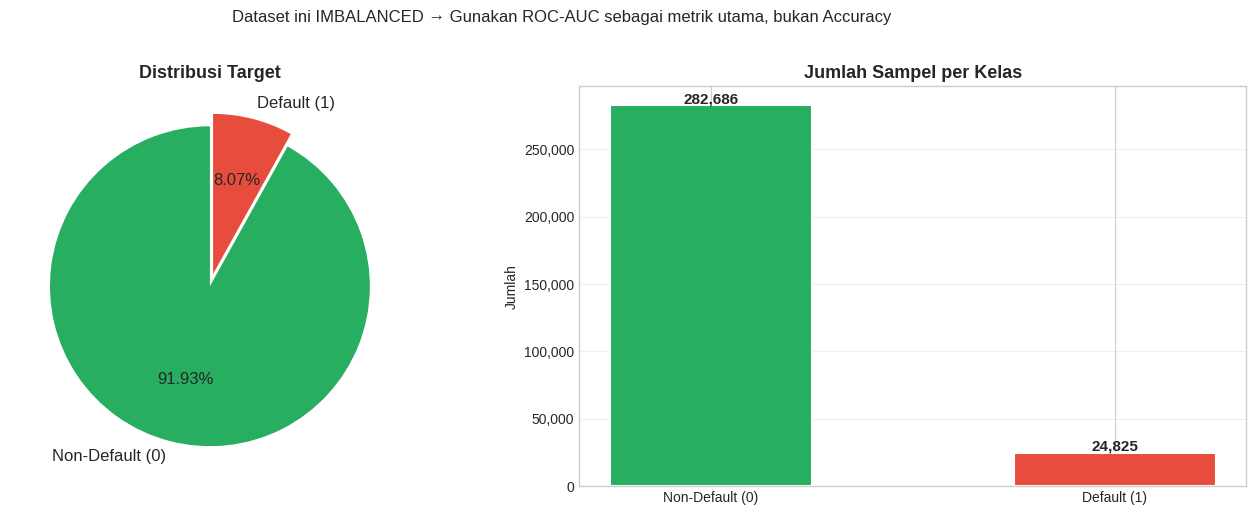

In [8]:
# ── 4A. DISTRIBUSI TARGET ─────────────────────────────────────
print("=" * 60)
print("EDA 4A: DISTRIBUSI TARGET")
print("=" * 60)

target_counts = app_train['TARGET'].value_counts()
print(f"Non-Default (0): {target_counts[0]:,}  ({target_counts[0]/len(app_train)*100:.1f}%)")
print(f"Default     (1): {target_counts[1]:,}  ({target_counts[1]/len(app_train)*100:.1f}%)")
print(f"Rasio imbalance: {target_counts[0]/target_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    target_counts,
    labels=['Non-Default (0)', 'Default (1)'],
    autopct='%1.2f%%',
    colors=['#27ae60', '#e74c3c'],
    explode=(0, 0.08),
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Distribusi Target', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Non-Default (0)', 'Default (1)'],
                   target_counts.values,
                   color=['#27ae60', '#e74c3c'],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Dataset ini IMBALANCED → Gunakan ROC-AUC sebagai metrik utama, bukan Accuracy',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


EDA 4B: MISSING VALUES
Kolom dengan missing values : 67 dari 122
Kolom dengan >50% missing   : 41
Kolom dengan 20-50% missing : 9

Top 15 kolom dengan missing terbanyak:
                          Missing Count  Missing %
COMMONAREA_MEDI                  214865    69.8723
COMMONAREA_MODE                  214865    69.8723
COMMONAREA_AVG                   214865    69.8723
NONLIVINGAPARTMENTS_MODE         213514    69.4330
NONLIVINGAPARTMENTS_MEDI         213514    69.4330
NONLIVINGAPARTMENTS_AVG          213514    69.4330
FONDKAPREMONT_MODE               210295    68.3862
LIVINGAPARTMENTS_AVG             210199    68.3550
LIVINGAPARTMENTS_MEDI            210199    68.3550
LIVINGAPARTMENTS_MODE            210199    68.3550
FLOORSMIN_MEDI                   208642    67.8486
FLOORSMIN_MODE                   208642    67.8486
FLOORSMIN_AVG                    208642    67.8486
YEARS_BUILD_MODE                 204488    66.4978
YEARS_BUILD_MEDI                 204488    66.4978


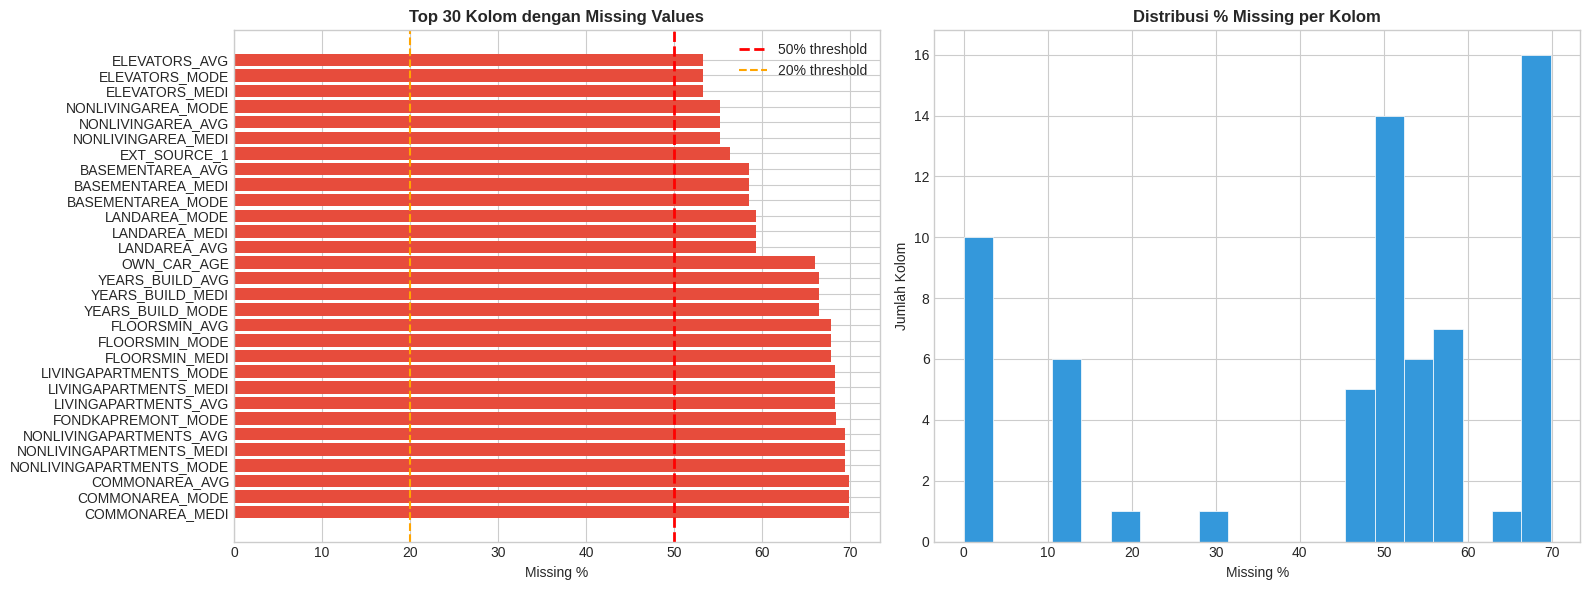

In [9]:
# ── 4B. MISSING VALUES ────────────────────────────────────────
print("=" * 60)
print("EDA 4B: MISSING VALUES")
print("=" * 60)

mv = missing_values_table(app_train)
print(f"Kolom dengan missing values : {len(mv)} dari {app_train.shape[1]}")
print(f"Kolom dengan >50% missing   : {(mv['Missing %'] > 50).sum()}")
print(f"Kolom dengan 20-50% missing : {((mv['Missing %'] > 20) & (mv['Missing %'] <= 50)).sum()}")
print("\nTop 15 kolom dengan missing terbanyak:")
print(mv.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_missing = mv.head(30)
colors_mv = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db'
             for x in top_missing['Missing %']]
axes[0].barh(top_missing.index, top_missing['Missing %'], color=colors_mv)
axes[0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
axes[0].axvline(x=20, color='orange', linestyle='--', linewidth=1.5, label='20% threshold')
axes[0].set_title('Top 30 Kolom dengan Missing Values', fontweight='bold')
axes[0].set_xlabel('Missing %')
axes[0].legend()

axes[1].hist(mv['Missing %'], bins=20, color='#3498db', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi % Missing per Kolom', fontweight='bold')
axes[1].set_xlabel('Missing %')
axes[1].set_ylabel('Jumlah Kolom')

plt.tight_layout()
plt.show()


EDA 4C: ANOMALI — DAYS_EMPLOYED
Statistik DAYS_EMPLOYED (sebelum handling):
count   307511.0000
mean     63815.0459
std     141275.7665
min     -17912.0000
25%      -2760.0000
50%      -1213.0000
75%       -289.0000
max     365243.0000
Name: DAYS_EMPLOYED, dtype: float64

Jumlah nilai anomali (365243) : 55,374 (18.0%)
Default rate ANOMALI          : 5.40%
Default rate NON-ANOMALI      : 8.66%

→ INSIGHT: Nilai 365243 ≈ 1000 tahun = kode untuk pensiunan/tidak bekerja.
  Menariknya, kelompok ini memiliki default rate LEBIH RENDAH.
  Solusi: ganti dengan NaN + buat flag DAYS_EMPLOYED_ANOM.


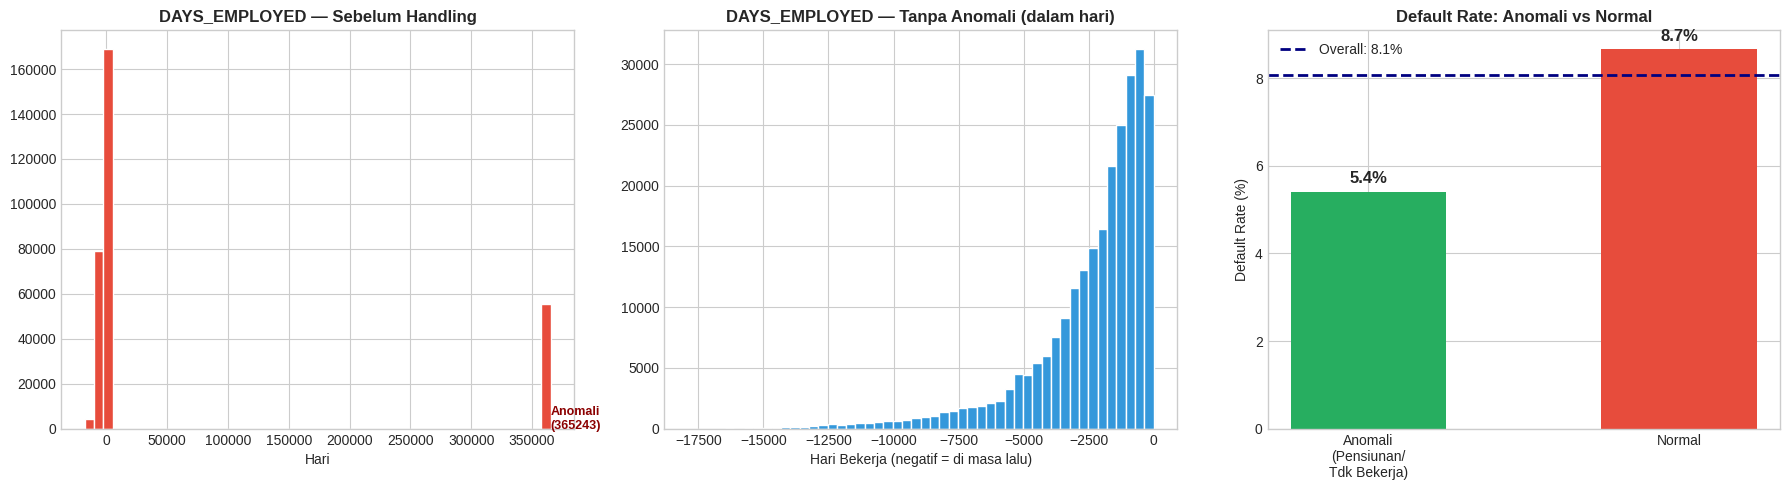

In [10]:
# ── 4C. ANOMALI: DAYS_EMPLOYED ───────────────────────────────
print("=" * 60)
print("EDA 4C: ANOMALI — DAYS_EMPLOYED")
print("=" * 60)

print("Statistik DAYS_EMPLOYED (sebelum handling):")
print(app_train['DAYS_EMPLOYED'].describe())
print()

anom_mask = app_train['DAYS_EMPLOYED'] == 365243
anom      = app_train[anom_mask]
non_anom  = app_train[~anom_mask]

print(f"Jumlah nilai anomali (365243) : {anom_mask.sum():,} ({anom_mask.mean()*100:.1f}%)")
print(f"Default rate ANOMALI          : {anom['TARGET'].mean()*100:.2f}%")
print(f"Default rate NON-ANOMALI      : {non_anom['TARGET'].mean()*100:.2f}%")
print("\n→ INSIGHT: Nilai 365243 ≈ 1000 tahun = kode untuk pensiunan/tidak bekerja.")
print("  Menariknya, kelompok ini memiliki default rate LEBIH RENDAH.")
print("  Solusi: ganti dengan NaN + buat flag DAYS_EMPLOYED_ANOM.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram sebelum handling
axes[0].hist(app_train['DAYS_EMPLOYED'].dropna(), bins=50, color='#e74c3c', edgecolor='white')
axes[0].set_title('DAYS_EMPLOYED — Sebelum Handling', fontweight='bold')
axes[0].set_xlabel('Hari')
axes[0].annotate('Anomali\n(365243)', xy=(365243, 10), fontsize=9, color='darkred',
                  fontweight='bold')

# Histogram setelah remove anomali
axes[1].hist(non_anom['DAYS_EMPLOYED'].dropna(), bins=50, color='#3498db', edgecolor='white')
axes[1].set_title('DAYS_EMPLOYED — Tanpa Anomali (dalam hari)', fontweight='bold')
axes[1].set_xlabel('Hari Bekerja (negatif = di masa lalu)')

# Default rate perbandingan
bars = axes[2].bar(['Anomali\n(Pensiunan/\nTdk Bekerja)', 'Normal'],
                   [anom['TARGET'].mean()*100, non_anom['TARGET'].mean()*100],
                   color=['#27ae60', '#e74c3c'], width=0.5)
for bar, v in zip(bars, [anom['TARGET'].mean()*100, non_anom['TARGET'].mean()*100]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].axhline(y=app_train['TARGET'].mean()*100, color='navy', linestyle='--',
                 linewidth=2, label=f"Overall: {app_train['TARGET'].mean()*100:.1f}%")
axes[2].set_title('Default Rate: Anomali vs Normal', fontweight='bold')
axes[2].set_ylabel('Default Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


EDA 4D: KORELASI FITUR vs TARGET
10 Korelasi POSITIF terkuat (semakin tinggi → risiko naik):
DAYS_REGISTRATION             0.0420
FLAG_DOCUMENT_3               0.0443
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_EMP_PHONE                0.0460
REG_CITY_NOT_WORK_CITY        0.0510
DAYS_ID_PUBLISH               0.0515
DAYS_LAST_PHONE_CHANGE        0.0552
REGION_RATING_CLIENT          0.0589
REGION_RATING_CLIENT_W_CITY   0.0609
DAYS_BIRTH                    0.0782

10 Korelasi NEGATIF terkuat (semakin tinggi → risiko turun):
EXT_SOURCE_3                 -0.1789
EXT_SOURCE_2                 -0.1605
EXT_SOURCE_1                 -0.1553
DAYS_EMPLOYED                -0.0449
FLOORSMAX_AVG                -0.0440
FLOORSMAX_MEDI               -0.0438
FLOORSMAX_MODE               -0.0432
AMT_GOODS_PRICE              -0.0396
REGION_POPULATION_RELATIVE   -0.0372
ELEVATORS_AVG                -0.0342


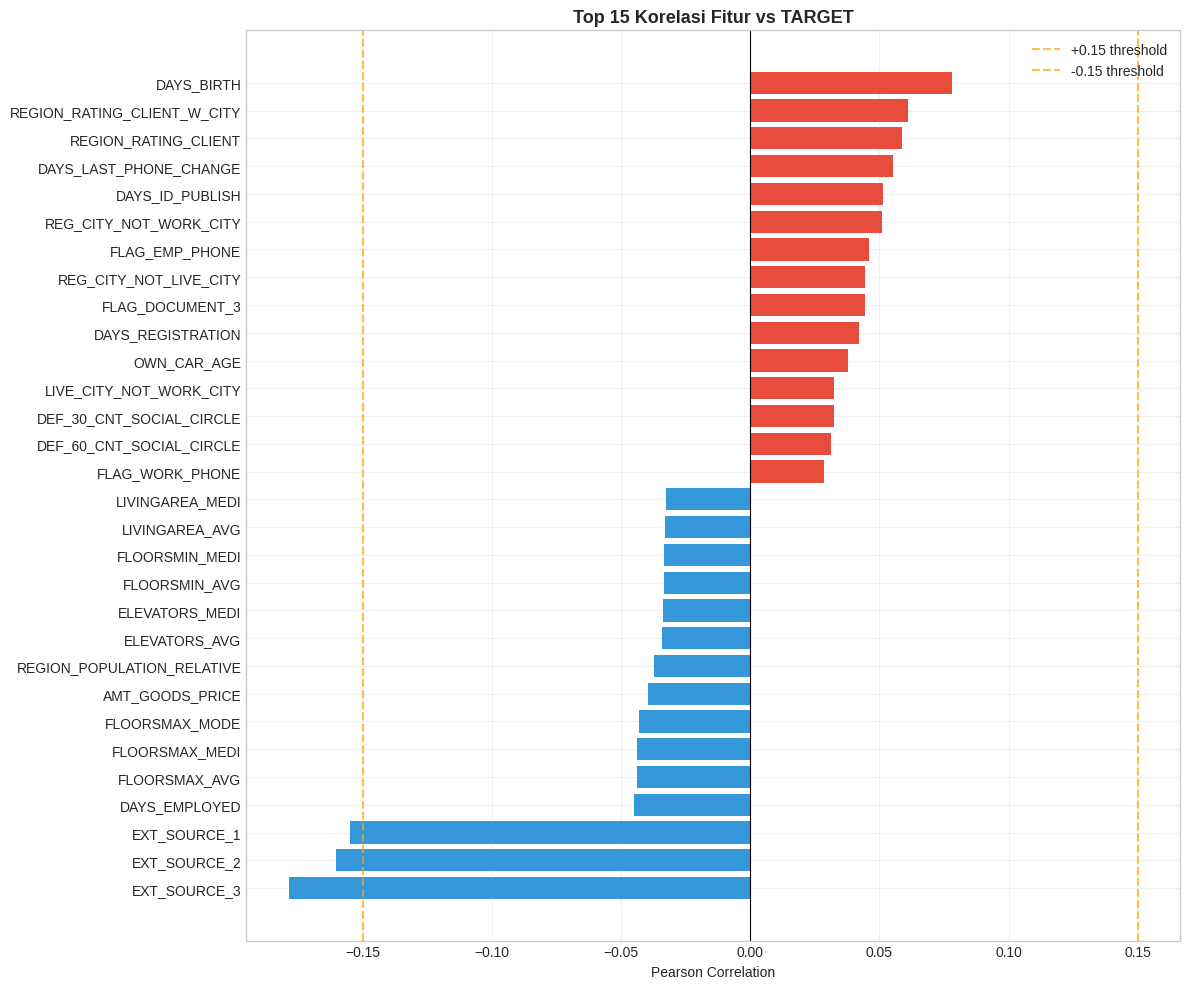

In [11]:
# ── 4D. KORELASI FITUR DENGAN TARGET ─────────────────────────
print("=" * 60)
print("EDA 4D: KORELASI FITUR vs TARGET")
print("=" * 60)

correlations = app_train.select_dtypes(include=[np.number]).corr()['TARGET'].drop('TARGET').sort_values()

print("10 Korelasi POSITIF terkuat (semakin tinggi → risiko naik):")
print(correlations.tail(10).to_string())
print("\n10 Korelasi NEGATIF terkuat (semakin tinggi → risiko turun):")
print(correlations.head(10).to_string())

fig, ax = plt.subplots(figsize=(12, 10))
top_pos = correlations.tail(15)
top_neg = correlations.head(15)
combined = pd.concat([top_neg, top_pos]).sort_values()

bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in combined.values]
ax.barh(combined.index, combined.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.15, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='+0.15 threshold')
ax.axvline(-0.15, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='-0.15 threshold')
ax.set_title('Top 15 Korelasi Fitur vs TARGET', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



INSIGHT:
- Korelasi semua fitur sangat lemah (< 0.2) — ini normal untuk data kredit!
- EXT_SOURCE_2 dan EXT_SOURCE_3 adalah fitur paling berkorelasi dengan target.
- DAYS_BIRTH (usia) berkorelasi negatif → semakin tua, lebih jarang default.
- Model non-linear (LightGBM/XGBoost) diperlukan untuk menangkap pola kompleks.


EDA 4E: EXT_SOURCE & DAYS_BIRTH (USIA)
Statistik EXT_SOURCE:
       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
count   134133.0000   306851.0000   246546.0000
mean         0.5021        0.5144        0.5109
std          0.2111        0.1911        0.1948
min          0.0146        0.0000        0.0005
25%          0.3340        0.3925        0.3706
50%          0.5060        0.5660        0.5353
75%          0.6751        0.6636        0.6691
max          0.9627        0.8550        0.8960



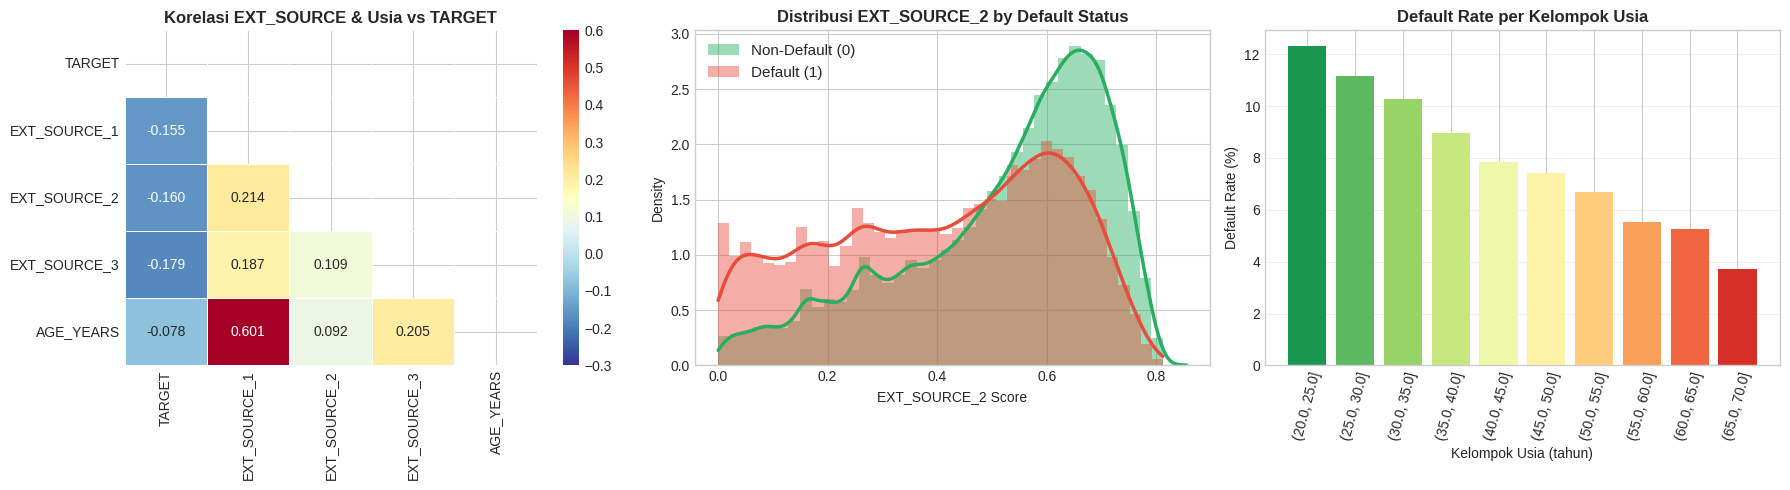

In [12]:
# ── 4E. ANALISIS EXT_SOURCE & USIA ───────────────────────────
print("=" * 60)
print("EDA 4E: EXT_SOURCE & DAYS_BIRTH (USIA)")
print("=" * 60)

ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']].copy()
ext_data['AGE_YEARS'] = -ext_data['DAYS_BIRTH'] / 365

print("Statistik EXT_SOURCE:")
print(ext_data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].describe())
print()

ext_corrs = ext_data.drop('DAYS_BIRTH', axis=1).corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap korelasi
mask = np.zeros_like(ext_corrs, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(ext_corrs, mask=mask, cmap='RdYlBu_r', annot=True, fmt='.3f',
            vmin=-0.3, vmax=0.6, ax=axes[0], linewidths=0.5)
axes[0].set_title('Korelasi EXT_SOURCE & Usia vs TARGET', fontweight='bold')

# KDE EXT_SOURCE_2
for t, color, label in [(0, '#27ae60', 'Non-Default (0)'), (1, '#e74c3c', 'Default (1)')]:
    data = ext_data[ext_data['TARGET'] == t]['EXT_SOURCE_2'].dropna()
    axes[1].hist(data, bins=40, alpha=0.45, color=color, label=label, density=True)
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = gaussian_kde(data)
    axes[1].plot(kde_x, kde(kde_x), color=color, linewidth=2.5)
axes[1].set_title('Distribusi EXT_SOURCE_2 by Default Status', fontweight='bold')
axes[1].set_xlabel('EXT_SOURCE_2 Score')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=11)

# Default Rate per Age Group
app_train['AGE_YEARS_TEMP'] = abs(app_train['DAYS_BIRTH']) / 365
age_data = app_train[['TARGET', 'AGE_YEARS_TEMP']].copy()
age_data['AGE_BIN'] = pd.cut(age_data['AGE_YEARS_TEMP'],
                              bins=np.linspace(20, 70, num=11))
age_groups = age_data.groupby('AGE_BIN')['TARGET'].mean()
axes[2].bar(age_groups.index.astype(str), age_groups.values * 100,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(age_groups))))
axes[2].set_title('Default Rate per Kelompok Usia', fontweight='bold')
axes[2].set_xlabel('Kelompok Usia (tahun)')
axes[2].set_ylabel('Default Rate (%)')
axes[2].tick_params(axis='x', rotation=75)
axes[2].grid(True, alpha=0.3, axis='y')
app_train.drop(columns=['AGE_YEARS_TEMP'], inplace=True)

plt.tight_layout()
plt.show()




KEY INSIGHTS:
- EXT_SOURCE_2 & EXT_SOURCE_3 → fitur terpenting, semakin TINGGI = risiko MAKIN RENDAH
- Peminjam usia < 30 tahun → default rate paling tinggi
- Peminjam usia > 50 tahun → default rate paling rendah

---
## Cell 5 — Data Cleaning

Berdasarkan temuan EDA, kita akan:
1. Handle anomali `DAYS_EMPLOYED` (nilai 365243)
2. Buat missing flags untuk fitur penting
3. Binary encoding untuk variabel ya/tidak
4. Capping outlier ekstrem
5. Hitung total dokumen yang diserahkan


In [13]:
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

def clean_application_data(df, is_train=True):
    df = df.copy()
    eps = 1e-8

    # 1. Handle anomali DAYS_EMPLOYED (365243 = pensiunan / tidak bekerja)
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(np.int8)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 2. Missing flags untuk fitur penting
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'OCCUPATION_TYPE']:
        if col in df.columns:
            df[f'{col}_MISSING'] = df[col].isna().astype(np.int8)

    # 3. Binary encoding
    df['CODE_GENDER']     = df['CODE_GENDER'].map({'M': 1, 'F': 0, 'XNA': 0}).fillna(0).astype(np.int8)
    df['FLAG_OWN_CAR']    = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0}).fillna(0).astype(np.int8)
    df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0}).fillna(0).astype(np.int8)

    # 4. Capping outlier AMT_INCOME_TOTAL & AMT_CREDIT (99th percentile)
    if 'AMT_INCOME_TOTAL' in df.columns:
        cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
        df['INCOME_OUTLIER'] = (df['AMT_INCOME_TOTAL'] > cap).astype(np.int8)
        df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=cap)
    if 'AMT_CREDIT' in df.columns:
        df['AMT_CREDIT'] = df['AMT_CREDIT'].clip(upper=df['AMT_CREDIT'].quantile(0.99))

    # 5. Hitung jumlah dokumen yang diserahkan
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if doc_cols:
        df['DOCS_SUBMITTED_COUNT'] = df[doc_cols].sum(axis=1).astype(np.int8)

    # 6. Fill nilai NaN pada kolom kategorikal dengan 'XNA'
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna('XNA')

    return df

print("Cleaning Training Data...")
df_train = clean_application_data(app_train, is_train=True)

if app_test is not None:
    print("\nCleaning Test Data...")
    df_test = clean_application_data(app_test, is_train=False)
else:
    df_test = None

print(f"\nShape setelah cleaning:")
print(f"  df_train: {df_train.shape}")
print(f"  df_test : {df_test.shape if df_test is not None else 'N/A'}")

# Konfirmasi anomali berhasil ditangani
print(f"\nKonfirmasi: nilai DAYS_EMPLOYED_ANOM = 1: {df_train['DAYS_EMPLOYED_ANOM'].sum():,} baris")
print(f"DAYS_EMPLOYED setelah cleaning (max): {df_train['DAYS_EMPLOYED'].max():.0f} hari")


DATA CLEANING
Cleaning Training Data...

Cleaning Test Data...

Shape setelah cleaning:
  df_train: (307511, 131)
  df_test : (48744, 130)

Konfirmasi: nilai DAYS_EMPLOYED_ANOM = 1: 55,374 baris
DAYS_EMPLOYED setelah cleaning (max): 0 hari


In [14]:
# Lihat kolom-kolom baru yang ditambahkan
new_cols = [c for c in df_train.columns if c not in app_train.columns]
print(f"Kolom baru setelah cleaning: {len(new_cols)}")
print(new_cols)

# Preview hasil cleaning
df_train[['DAYS_EMPLOYED', 'DAYS_EMPLOYED_ANOM',
          'EXT_SOURCE_1', 'EXT_SOURCE_1_MISSING',
          'CODE_GENDER', 'FLAG_OWN_CAR', 'DOCS_SUBMITTED_COUNT']].head(10)


Kolom baru setelah cleaning: 9
['DAYS_EMPLOYED_ANOM', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'AMT_GOODS_PRICE_MISSING', 'AMT_ANNUITY_MISSING', 'OCCUPATION_TYPE_MISSING', 'INCOME_OUTLIER', 'DOCS_SUBMITTED_COUNT']


,DAYS_EMPLOYED,DAYS_EMPLOYED_ANOM,EXT_SOURCE_1,EXT_SOURCE_1_MISSING,CODE_GENDER,FLAG_OWN_CAR,DOCS_SUBMITTED_COUNT
0,-637.0000,0,0.0830,0,1,0,1
1,-1188.0000,0,0.3113,0,0,0,1
2,-225.0000,0,NaN,1,1,1,0
3,-3039.0000,0,NaN,1,0,0,1
4,-3038.0000,0,NaN,1,1,0,1
5,-1588.0000,0,NaN,1,1,0,1
6,-3130.0000,0,0.7748,0,0,1,2
7,-449.0000,0,NaN,1,1,1,1
8,NaN,1,0.5873,0,0,0,1
9,-2019.0000,0,NaN,1,1,0,0


---
## Cell 6 — Feature Engineering: Application Data

> **Mengapa Feature Engineering penting?**
> Korelasi fitur mentah sangat lemah. Dengan menciptakan fitur baru yang bermakna secara bisnis
> (rasio kredit/pendapatan, interaksi EXT_SOURCE, dll.), model akan jauh lebih mampu mendeteksi pola risiko.

Kita buat **50+ fitur baru** dari:
- **Time-based**: usia, lama bekerja, rasio waktu
- **Financial ratios**: kredit/pendapatan, anuitas, uang muka
- **EXT_SOURCE combinations**: mean, std, weighted, product
- **Risk flags**: binary indicator untuk kondisi berisiko tinggi
- **Interaction features**: kombinasi fitur terpenting


In [15]:
print("=" * 60)
print("FEATURE ENGINEERING — APPLICATION DATA")
print("=" * 60)

def create_app_features(df):
    df = df.copy()
    eps = 1e-8

    # ── 1. TIME-BASED FEATURES ────────────────────────────────
    df['AGE_YEARS']           = (-df['DAYS_BIRTH'] / 365).astype(np.float32)
    df['EMPLOYED_YEARS']      = (-df['DAYS_EMPLOYED'] / 365).astype(np.float32)
    df['REGISTRATION_YEARS']  = (-df['DAYS_REGISTRATION'] / 365).astype(np.float32)
    df['ID_PUBLISH_YEARS']    = (-df['DAYS_ID_PUBLISH'] / 365).astype(np.float32)

    df['AGE_GROUP'] = pd.cut(
        df['AGE_YEARS'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    )
    df['EMPLOYED_TO_AGE_RATIO'] = (df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + eps)).astype(np.float32)
    df['LONG_TERM_EMPLOYED']    = (df['EMPLOYED_YEARS'] > 5).astype(np.int8)
    df['NEW_EMPLOYEE']          = (df['EMPLOYED_YEARS'] < 1).astype(np.int8)

    # ── 2. FINANCIAL RATIO FEATURES ───────────────────────────
    df['CREDIT_INCOME_RATIO']   = (df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + eps)).astype(np.float32)
    df['ANNUITY_INCOME_RATIO']  = (df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + eps)).astype(np.float32)
    df['CREDIT_ANNUITY_RATIO']  = (df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + eps)).astype(np.float32)
    df['CREDIT_GOODS_RATIO']    = (df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + eps)).astype(np.float32)
    df['PAYMENT_BURDEN']        = (df['AMT_ANNUITY'] * 12 / (df['AMT_INCOME_TOTAL'] + eps)).astype(np.float32)
    df['CREDIT_TERM_YEARS']     = (df['AMT_CREDIT'] / (df['AMT_ANNUITY'] * 12 + eps)).astype(np.float32)

    df['DOWNPAYMENT']           = (df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']).clip(lower=0).astype(np.float32)
    df['DOWNPAYMENT_RATIO']     = (df['DOWNPAYMENT'] / (df['AMT_GOODS_PRICE'] + eps)).astype(np.float32)

    # Risk flags berbasis rasio keuangan
    df['HIGH_CREDIT_INCOME']    = (df['CREDIT_INCOME_RATIO'] > 4).astype(np.int8)
    df['HIGH_ANNUITY_INCOME']   = (df['ANNUITY_INCOME_RATIO'] > 0.5).astype(np.int8)
    df['ZERO_DOWNPAYMENT']      = (df['DOWNPAYMENT_RATIO'] < 0.01).astype(np.int8)

    # ── 3. EXT_SOURCE FEATURES (Terpenting!) ──────────────────
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    df['EXT_SOURCE_MEAN']     = df[ext_cols].mean(axis=1).astype(np.float32)
    df['EXT_SOURCE_STD']      = df[ext_cols].std(axis=1).astype(np.float32)
    df['EXT_SOURCE_MIN']      = df[ext_cols].min(axis=1).astype(np.float32)
    df['EXT_SOURCE_MAX']      = df[ext_cols].max(axis=1).astype(np.float32)
    df['EXT_SOURCE_PROD']     = (df['EXT_SOURCE_1'].fillna(0.5) *
                                  df['EXT_SOURCE_2'].fillna(0.5) *
                                  df['EXT_SOURCE_3'].fillna(0.5)).astype(np.float32)
    # Weighted: EXT_SOURCE_2 & 3 lebih penting berdasarkan korelasi
    df['EXT_SOURCE_WEIGHTED'] = (
        df['EXT_SOURCE_1'].fillna(0) * 0.2 +
        df['EXT_SOURCE_2'].fillna(0) * 0.4 +
        df['EXT_SOURCE_3'].fillna(0) * 0.4
    ).astype(np.float32)
    df['EXT_SOURCE_NANCOUNT'] = df[ext_cols].isna().sum(axis=1).astype(np.int8)
    df['ALL_EXT_MISSING']     = (df['EXT_SOURCE_NANCOUNT'] == 3).astype(np.int8)

    # Interaksi EXT_SOURCE × Usia
    df['EXT2_AGE']            = (df['EXT_SOURCE_2'] * df['AGE_YEARS'] / 100).astype(np.float32)
    df['EXT3_CREDIT']         = (df['EXT_SOURCE_3'] / (df['CREDIT_INCOME_RATIO'] + eps)).astype(np.float32)

    # ── 4. FITUR INTERAKSI LAINNYA ─────────────────────────────
    df['INCOME_PER_PERSON']   = (df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'].fillna(1) + eps)).astype(np.float32)
    df['CREDIT_PER_CHILD']    = (df['AMT_CREDIT'] / (df['CNT_CHILDREN'].fillna(0) + 1 + eps)).astype(np.float32)

    # ── 5. RISK FLAGS TAMBAHAN ─────────────────────────────────
    df['YOUNG_HIGH_CREDIT']   = ((df['AGE_YEARS'] < 30) & (df['CREDIT_INCOME_RATIO'] > 3)).astype(np.int8)
    df['NO_WORK_HISTORY']     = (df['DAYS_EMPLOYED_ANOM'] == 1).astype(np.int8)
    df['EXT_LOW_SCORE']       = (df['EXT_SOURCE_MEAN'] < 0.3).astype(np.int8)
    df['EXT_HIGH_SCORE']      = (df['EXT_SOURCE_MEAN'] > 0.6).astype(np.int8)

    return df

print("Membuat fitur untuk training data...")
df_train = create_app_features(df_train)

if df_test is not None:
    print("Membuat fitur untuk test data...")
    df_test = create_app_features(df_test)

new_features = [c for c in df_train.columns if c not in app_train.columns and c not in ['TARGET']]
print(f"\nJumlah fitur baru ditambahkan: {len(new_features)}")
print(f"Total kolom df_train: {df_train.shape[1]}")


FEATURE ENGINEERING — APPLICATION DATA
Membuat fitur untuk training data...
Membuat fitur untuk test data...

Jumlah fitur baru ditambahkan: 44
Total kolom df_train: 166


In [16]:
# Lihat distribusi beberapa fitur baru yang dibuat
print("Preview fitur baru yang dibuat:")
new_feat_cols = ['AGE_YEARS', 'EMPLOYED_YEARS', 'CREDIT_INCOME_RATIO',
                 'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED', 'PAYMENT_BURDEN',
                 'YOUNG_HIGH_CREDIT', 'EXT_LOW_SCORE']
df_train[new_feat_cols].head(10)


Preview fitur baru yang dibuat:


,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_WEIGHTED,PAYMENT_BURDEN,YOUNG_HIGH_CREDIT,EXT_LOW_SCORE
0,25.9205,1.7452,2.0079,0.1618,0.1775,1.4637,0,1
1,45.9315,3.2548,4.7908,0.4668,0.3112,1.5866,0,0
2,52.1808,0.6164,2.0000,0.6427,0.5142,1.2000,0,0
3,52.0685,8.3260,2.3162,0.6504,0.2602,2.6388,0,0
4,54.6082,8.3233,4.2222,0.3227,0.1291,2.1596,0,0
5,46.4137,4.3507,4.9545,0.4877,0.3902,3.3355,0,0
6,37.7479,8.5753,9.1271,0.6636,0.6414,2.8983,0,0
7,51.6438,1.2301,4.2500,0.6275,0.5020,1.4025,0,0
8,55.0658,NaN,9.0632,0.5149,0.5005,3.6082,0,0
9,39.6411,5.5315,3.0000,0.7466,0.2987,1.8000,0,0


In [17]:
# ============================================================
# VERIFIKASI FEATURE ENGINEERING
# ============================================================

print("=" * 60)
print("VERIFIKASI: KORELASI FITUR BARU vs TARGET")
print("=" * 60)

# Fitur engineered baru
new_corr_cols = [
    'AGE_YEARS', 'EMPLOYED_YEARS', 'CREDIT_INCOME_RATIO',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED', 'EXT_SOURCE_PROD',
    'PAYMENT_BURDEN', 'DOWNPAYMENT_RATIO', 'YOUNG_HIGH_CREDIT'
]

corr_new = df_train[new_corr_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

print("Korelasi fitur baru vs TARGET:")
print(corr_new.to_string())

VERIFIKASI: KORELASI FITUR BARU vs TARGET
Korelasi fitur baru vs TARGET:
EXT_SOURCE_MEAN       -0.2221
EXT_SOURCE_PROD       -0.1895
EXT_SOURCE_WEIGHTED   -0.1865
AGE_YEARS             -0.0782
EMPLOYED_YEARS        -0.0750
DOWNPAYMENT_RATIO     -0.0102
CREDIT_INCOME_RATIO   -0.0076
PAYMENT_BURDEN         0.0139
YOUNG_HIGH_CREDIT      0.0400


In [18]:
# ============================================================
# PERBANDINGAN EXT_SOURCE RAW vs ENGINEERED
# ============================================================

print("\n" + "=" * 60)
print("PERBANDINGAN EXT_SOURCE RAW vs ENGINEERED")
print("=" * 60)

raw_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
engineered_cols = ['EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED', 'EXT_SOURCE_PROD']

corr_compare = (
    df_train[raw_cols + engineered_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

print("\nKorelasi EXT_SOURCE:")
print(corr_compare.to_string())


PERBANDINGAN EXT_SOURCE RAW vs ENGINEERED

Korelasi EXT_SOURCE:
EXT_SOURCE_MEAN       -0.2221
EXT_SOURCE_PROD       -0.1895
EXT_SOURCE_WEIGHTED   -0.1865
EXT_SOURCE_3          -0.1789
EXT_SOURCE_2          -0.1605
EXT_SOURCE_1          -0.1553


In [19]:
# ============================================================
# TOP ENGINEERED FEATURES
# ============================================================

engineered_corr = corr_compare[engineered_cols].abs().sort_values(ascending=False)
top_engineered = engineered_corr.head(2)

print("\nTop Engineered Features:")
print(top_engineered.to_string())


Top Engineered Features:
EXT_SOURCE_MEAN   0.2221
EXT_SOURCE_PROD   0.1895


In [20]:

# ============================================================
# KESIMPULAN
# ============================================================

best_raw_feature = corr_compare[raw_cols].abs().idxmax()
best_raw_value = corr_compare[raw_cols].abs().max()

best_engineered_feature = corr_compare[engineered_cols].abs().idxmax()
best_engineered_value = corr_compare[engineered_cols].abs().max()

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

print(f"Fitur mentah terkuat      : {best_raw_feature} (|corr| = {best_raw_value:.4f})")
print(f"Fitur engineered terkuat  : {best_engineered_feature} (|corr| = {best_engineered_value:.4f})")

if best_engineered_value > best_raw_value:
    print(f"\n→ Pada data ini, feature engineering menghasilkan fitur yang lebih kuat terhadap TARGET,")
    print(f"  yaitu {best_engineered_feature}, dibanding fitur mentah terbaik {best_raw_feature}.")
elif best_engineered_value < best_raw_value:
    print(f"\n→ Pada data ini, fitur mentah masih lebih kuat terhadap TARGET,")
    print(f"  yaitu {best_raw_feature}, dibanding fitur engineered terbaik {best_engineered_feature}.")
else:
    print(f"\n→ Pada data ini, fitur engineered dan fitur mentah memiliki kekuatan korelasi yang setara terhadap TARGET.")

print("\n→ Dua fitur engineered dengan korelasi terkuat:")
for feat, val in top_engineered.items():
    print(f"   • {feat} (|corr| = {val:.4f})")

print("\nCatatan:")
print("Korelasi hanya menunjukkan hubungan linear dengan TARGET,")
print("bukan jaminan langsung bahwa fitur tersebut pasti paling penting dalam model final.")


KESIMPULAN
Fitur mentah terkuat      : EXT_SOURCE_3 (|corr| = 0.1789)
Fitur engineered terkuat  : EXT_SOURCE_MEAN (|corr| = 0.2221)

→ Pada data ini, feature engineering menghasilkan fitur yang lebih kuat terhadap TARGET,
  yaitu EXT_SOURCE_MEAN, dibanding fitur mentah terbaik EXT_SOURCE_3.

→ Dua fitur engineered dengan korelasi terkuat:
   • EXT_SOURCE_MEAN (|corr| = 0.2221)
   • EXT_SOURCE_PROD (|corr| = 0.1895)

Catatan:
Korelasi hanya menunjukkan hubungan linear dengan TARGET,
bukan jaminan langsung bahwa fitur tersebut pasti paling penting dalam model final.


---
## Cell 7 — Agregasi Data Tambahan

Kita akan menggabungkan informasi dari 5 tabel pendukung. Karena setiap peminjam bisa punya banyak baris di tabel-tabel ini, kita perlu melakukan **agregasi** (mean, sum, max, count) agar setiap peminjam hanya punya 1 baris representasi.


In [21]:
print("=" * 60)
print("AGREGASI BUREAU DATA")
print("=" * 60)

def aggregate_bureau(bureau_df, bb_df):
    if bureau_df is None: return None
    bureau_df = bureau_df.copy()
    eps = 1e-8

    # Gabungkan bureau_balance
    if bb_df is not None:
        bb = bb_df[bb_df['MONTHS_BALANCE'] <= 0].copy()
        status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
        bb['STATUS_NUM'] = bb['STATUS'].map(status_map).fillna(0).astype(np.int8)
        bb['HAS_DPD']    = (bb['STATUS_NUM'] > 0).astype(np.int8)
        bb_agg = bb.groupby('SK_ID_BUREAU').agg({
            'STATUS_NUM': ['mean', 'max'],
            'HAS_DPD': ['sum', 'mean'],
            'MONTHS_BALANCE': ['count', 'min']
        })
        bb_agg.columns = ['BB_' + '_'.join(col).upper() for col in bb_agg.columns]
        bureau_df = bureau_df.merge(bb_agg.reset_index(), on='SK_ID_BUREAU', how='left')
        del bb, bb_agg; gc.collect()

    bureau_df['DEBT_RATIO']    = bureau_df['AMT_CREDIT_SUM_DEBT'] / (bureau_df['AMT_CREDIT_SUM'] + eps)
    bureau_df['OVERDUE_RATIO'] = bureau_df['AMT_CREDIT_SUM_OVERDUE'] / (bureau_df['AMT_CREDIT_SUM'] + eps)
    bureau_df['HAS_OVERDUE']   = (bureau_df['CREDIT_DAY_OVERDUE'] > 0).astype(np.int8)
    bureau_df['IS_ACTIVE']     = (bureau_df['CREDIT_ACTIVE'] == 'Active').astype(np.int8)

    agg_dict = {
        'SK_ID_BUREAU': 'count',
        'DAYS_CREDIT': ['mean', 'min', 'max'],
        'AMT_CREDIT_SUM': ['mean', 'sum', 'max'],
        'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean', 'sum'],
        'CREDIT_DAY_OVERDUE': ['mean', 'max'],
        'DEBT_RATIO': ['mean', 'max'],
        'HAS_OVERDUE': ['sum', 'mean'],
        'IS_ACTIVE': ['sum', 'mean'],
    }
    for col in [c for c in bureau_df.columns if c.startswith('BB_')]:
        if bureau_df[col].notna().any():
            agg_dict[col] = ['mean', 'max']

    agg = bureau_df.groupby('SK_ID_CURR').agg(agg_dict)
    agg.columns = ['BUREAU_' + '_'.join(str(c) for c in col).upper() for col in agg.columns]
    agg = agg.reset_index().rename(columns={'BUREAU_SK_ID_BUREAU_COUNT': 'BUREAU_COUNT'})

    agg['BUREAU_TOTAL_DEBT_RATIO']  = agg['BUREAU_AMT_CREDIT_SUM_DEBT_SUM'] / (agg['BUREAU_AMT_CREDIT_SUM_SUM'] + eps)
    agg['BUREAU_HIGH_DEBT_FLAG']    = (agg['BUREAU_TOTAL_DEBT_RATIO'] > 0.8).astype(np.int8)
    agg['BUREAU_MANY_CREDITS_FLAG'] = (agg['BUREAU_COUNT'] > 10).astype(np.int8)

    return reduce_memory(agg, verbose=False)

bureau_agg = aggregate_bureau(bureau, bureau_bal)
if bureau_agg is not None:
    print(f"Bureau agg shape: {bureau_agg.shape}")
    print("Preview:")
    print(bureau_agg.head(3).to_string())


AGREGASI BUREAU DATA
Bureau agg shape: (305811, 35)
Preview:
   SK_ID_CURR  BUREAU_COUNT  BUREAU_DAYS_CREDIT_MEAN  BUREAU_DAYS_CREDIT_MIN  BUREAU_DAYS_CREDIT_MAX  BUREAU_AMT_CREDIT_SUM_MEAN  BUREAU_AMT_CREDIT_SUM_SUM  BUREAU_AMT_CREDIT_SUM_MAX  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN  BUREAU_AMT_CREDIT_SUM_DEBT_SUM  BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN  BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM  BUREAU_CREDIT_DAY_OVERDUE_MEAN  BUREAU_CREDIT_DAY_OVERDUE_MAX  BUREAU_DEBT_RATIO_MEAN  BUREAU_DEBT_RATIO_MAX  BUREAU_HAS_OVERDUE_SUM  BUREAU_HAS_OVERDUE_MEAN  BUREAU_IS_ACTIVE_SUM  BUREAU_IS_ACTIVE_MEAN  BUREAU_BB_STATUS_NUM_MEAN_MEAN  BUREAU_BB_STATUS_NUM_MEAN_MAX  BUREAU_BB_STATUS_NUM_MAX_MEAN  BUREAU_BB_STATUS_NUM_MAX_MAX  BUREAU_BB_HAS_DPD_SUM_MEAN  BUREAU_BB_HAS_DPD_SUM_MAX  BUREAU_BB_HAS_DPD_MEAN_MEAN  BUREAU_BB_HAS_DPD_MEAN_MAX  BUREAU_BB_MONTHS_BALANCE_COUNT_MEAN  BUREAU_BB_MONTHS_BALANCE_COUNT_MAX  BUREAU_BB_MONTHS_BALANCE_MIN_MEAN  BUREAU_BB_MONTHS_BALANCE_MIN_MAX  BUREAU_TOTAL_DEBT_RATIO  BUREAU_HIGH_

In [22]:
print("=" * 60)
print("AGREGASI PREVIOUS APPLICATION")
print("=" * 60)

def aggregate_previous(prev_df):
    if prev_df is None: return None
    prev_df = prev_df.replace(['XNA', 'XAP'], np.nan).copy()
    eps = 1e-8

    prev_df['CREDIT_GOODS_RATIO']   = prev_df['AMT_CREDIT'] / (prev_df['AMT_GOODS_PRICE'] + eps)
    prev_df['DOWN_PAYMENT_RATIO']   = prev_df['AMT_DOWN_PAYMENT'].fillna(0) / (prev_df['AMT_GOODS_PRICE'] + eps)
    prev_df['ANNUITY_CREDIT_RATIO'] = prev_df['AMT_ANNUITY'] / (prev_df['AMT_CREDIT'] + eps)
    prev_df['IS_APPROVED']  = (prev_df['NAME_CONTRACT_STATUS'] == 'Approved').astype(np.int8)
    prev_df['IS_REFUSED']   = (prev_df['NAME_CONTRACT_STATUS'] == 'Refused').astype(np.int8)
    prev_df['IS_CANCELED']  = (prev_df['NAME_CONTRACT_STATUS'] == 'Canceled').astype(np.int8)

    agg = prev_df.groupby('SK_ID_CURR').agg({
        'SK_ID_PREV': 'count',
        'AMT_CREDIT': ['mean', 'sum', 'max'],
        'AMT_ANNUITY': ['mean', 'sum'],
        'AMT_APPLICATION': ['mean', 'sum'],
        'AMT_DOWN_PAYMENT': ['mean', 'sum'],
        'DAYS_DECISION': ['mean', 'min', 'max'],
        'CNT_PAYMENT': ['mean', 'sum'],
        'CREDIT_GOODS_RATIO': ['mean', 'max'],
        'DOWN_PAYMENT_RATIO': ['mean', 'max'],
        'IS_APPROVED': ['sum', 'mean'],
        'IS_REFUSED': ['sum', 'mean'],
        'IS_CANCELED': ['sum', 'mean'],
    })
    agg.columns = ['PREV_' + '_'.join(str(c) for c in col).upper() for col in agg.columns]
    agg = agg.reset_index().rename(columns={'PREV_SK_ID_PREV_COUNT': 'PREV_COUNT'})

    agg['PREV_APPROVAL_RATE']     = agg['PREV_IS_APPROVED_SUM'] / (agg['PREV_COUNT'] + eps)
    agg['PREV_REFUSAL_RATE']      = agg['PREV_IS_REFUSED_SUM'] / (agg['PREV_COUNT'] + eps)
    agg['PREV_HIGH_REFUSAL_FLAG'] = (agg['PREV_REFUSAL_RATE'] > 0.5).astype(np.int8)

    return reduce_memory(agg, verbose=False)


def aggregate_installments(inst_df):
    if inst_df is None: return None
    inst_df = inst_df.copy()
    eps = 1e-8
    inst_df['PAYMENT_RATIO'] = inst_df['AMT_PAYMENT'] / (inst_df['AMT_INSTALMENT'] + eps)
    inst_df['DAYS_DIFF']     = inst_df['DAYS_ENTRY_PAYMENT'] - inst_df['DAYS_INSTALMENT']
    inst_df['PAID_LATE']     = (inst_df['DAYS_DIFF'] > 0).astype(np.int8)
    inst_df['DAYS_LATE']     = inst_df['DAYS_DIFF'].clip(lower=0)
    inst_df['DPD_30']        = (inst_df['DAYS_LATE'] > 30).astype(np.int8)

    agg = inst_df.groupby('SK_ID_CURR').agg({
        'SK_ID_PREV': ['count', 'nunique'],
        'AMT_INSTALMENT': ['mean', 'sum', 'max'],
        'AMT_PAYMENT': ['mean', 'sum'],
        'PAYMENT_RATIO': ['mean', 'min', 'max'],
        'DAYS_LATE': ['mean', 'max', 'sum'],
        'PAID_LATE': ['sum', 'mean'],
        'DPD_30': ['sum', 'mean'],
    })
    agg.columns = ['INST_' + '_'.join(str(c) for c in col).upper() for col in agg.columns]
    agg = agg.reset_index()

    agg['INST_PAYMENT_DEFICIT'] = agg['INST_AMT_INSTALMENT_SUM'] - agg['INST_AMT_PAYMENT_SUM']
    agg['INST_HIGH_LATE_FLAG']  = (agg['INST_PAID_LATE_MEAN'] > 0.5).astype(np.int8)
    return reduce_memory(agg, verbose=False)


def aggregate_pos_cash(pos_df):
    if pos_df is None: return None
    pos_df = pos_df.copy()
    pos_df['HAS_DPD'] = (pos_df['SK_DPD'] > 0).astype(np.int8)
    pos_df['HAS_DPD_DEF'] = (pos_df['SK_DPD_DEF'] > 0).astype(np.int8)
    agg = pos_df.groupby('SK_ID_CURR').agg({
        'SK_ID_PREV': ['count', 'nunique'],
        'MONTHS_BALANCE': ['count', 'min'],
        'CNT_INSTALMENT': ['mean', 'sum'],
        'SK_DPD': ['mean', 'max', 'sum'],
        'HAS_DPD': ['sum', 'mean'],
        'HAS_DPD_DEF': ['sum', 'mean'],
    })
    agg.columns = ['POS_' + '_'.join(str(c) for c in col).upper() for col in agg.columns]
    agg = agg.reset_index()
    agg['POS_HIGH_DPD_FLAG'] = (agg['POS_HAS_DPD_MEAN'] > 0.3).astype(np.int8)
    return reduce_memory(agg, verbose=False)


def aggregate_credit_card(cc_df):
    if cc_df is None: return None
    cc_df = cc_df.copy()
    eps = 1e-8
    cc_df['UTIL_RATIO'] = cc_df['AMT_BALANCE'] / (cc_df['AMT_CREDIT_LIMIT_ACTUAL'] + eps)
    cc_df['HAS_DPD']    = (cc_df['SK_DPD'] > 0).astype(np.int8)
    agg = cc_df.groupby('SK_ID_CURR').agg({
        'SK_ID_PREV': ['count', 'nunique'],
        'AMT_BALANCE': ['mean', 'max', 'sum'],
        'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],
        'AMT_DRAWINGS_CURRENT': ['mean', 'sum'],
        'UTIL_RATIO': ['mean', 'max'],
        'SK_DPD': ['mean', 'max'],
        'HAS_DPD': ['sum', 'mean'],
    })
    agg.columns = ['CC_' + '_'.join(str(c) for c in col).upper() for col in agg.columns]
    agg = agg.reset_index()
    agg['CC_HIGH_UTIL_FLAG'] = (agg['CC_UTIL_RATIO_MEAN'] > 0.7).astype(np.int8)
    return reduce_memory(agg, verbose=False)

# Jalankan semua agregasi
print("Memproses agregasi...")
prev_agg  = aggregate_previous(prev_app)
inst_agg  = aggregate_installments(installments)
pos_agg   = aggregate_pos_cash(pos_cash)
cc_agg    = aggregate_credit_card(credit_card)

for name, agg in [('Previous App', prev_agg), ('Installments', inst_agg),
                   ('POS Cash', pos_agg), ('Credit Card', cc_agg)]:
    if agg is not None:
        print(f"  {name}: {agg.shape}")


AGREGASI PREVIOUS APPLICATION
Memproses agregasi...
  Previous App: (338857, 29)
  Installments: (339587, 20)
  POS Cash: (337252, 15)
  Credit Card: (103558, 17)


In [23]:
print("=" * 60)
print("MERGE SEMUA TABEL KE MAIN DATA")
print("=" * 60)

def merge_all(main_df, bureau_agg, prev_agg, inst_agg, pos_agg, cc_agg):
    df = main_df.copy()
    for name, agg in [('Bureau', bureau_agg), ('Prev', prev_agg),
                       ('Inst', inst_agg), ('POS', pos_agg), ('CC', cc_agg)]:
        if agg is not None:
            before = df.shape[1]
            df = df.merge(agg, on='SK_ID_CURR', how='left')
            print(f"  + {name}: +{df.shape[1]-before} kolom")
    return df

print("Merge ke df_train:")
df_train = merge_all(df_train, bureau_agg, prev_agg, inst_agg, pos_agg, cc_agg)
print(f"  → df_train final: {df_train.shape}")

if df_test is not None:
    print("\nMerge ke df_test:")
    df_test = merge_all(df_test, bureau_agg, prev_agg, inst_agg, pos_agg, cc_agg)
    print(f"  → df_test final: {df_test.shape}")

gc.collect()
print("\nMerge selesai.")


MERGE SEMUA TABEL KE MAIN DATA
Merge ke df_train:
  + Bureau: +34 kolom
  + Prev: +28 kolom
  + Inst: +19 kolom
  + POS: +14 kolom
  + CC: +16 kolom
  → df_train final: (307511, 277)

Merge ke df_test:
  + Bureau: +34 kolom
  + Prev: +28 kolom
  + Inst: +19 kolom
  + POS: +14 kolom
  + CC: +16 kolom
  → df_test final: (48744, 276)

Merge selesai.


---
## Cell 8 — Encoding & Preprocessing

Setelah semua fitur tersedia, kita perlu:
1. Simpan TARGET dan ID sebelum di-drop
2. Label encoding untuk kolom kategorikal
3. Hapus kolom konstan (tidak informatif)
4. Pastikan kolom training dan test identik


In [24]:
print("=" * 60)
print("ENCODING & PREPROCESSING")
print("=" * 60)

# Simpan info penting
train_ids     = df_train['SK_ID_CURR'].copy()
test_ids      = df_test['SK_ID_CURR'].copy() if df_test is not None else None
credit_median = df_train['AMT_CREDIT'].median()
train_amt     = df_train['AMT_CREDIT'].fillna(credit_median).values
y             = df_train['TARGET'].values

print(f"Target distribusi: {dict(pd.Series(y).value_counts())}")
print(f"Default rate: {y.mean()*100:.2f}%")

# Drop kolom yang tidak perlu
drop_cols = ['TARGET', 'SK_ID_CURR', 'AGE_GROUP']
X_raw      = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
X_test_raw = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns]) if df_test is not None else None

cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n  Kolom kategorikal : {len(cat_cols)}")
print(f"  Kolom numerik     : {len(num_cols)}")
print(f"  Total fitur awal  : {X_raw.shape[1]}")

# Label Encoding
X_boost      = X_raw.replace([np.inf, -np.inf], np.nan).copy()
X_test_boost = X_test_raw.replace([np.inf, -np.inf], np.nan).copy() if X_test_raw is not None else None

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_boost[col] = X_boost[col].astype(str).fillna('XNA')
    le.fit(X_boost[col])
    X_boost[col] = le.transform(X_boost[col])

    if X_test_boost is not None and col in X_test_boost.columns:
        X_test_boost[col] = X_test_boost[col].astype(str).fillna('XNA')
        known = set(le.classes_)
        X_test_boost[col] = X_test_boost[col].apply(lambda x: x if x in known else 'XNA')
        if 'XNA' not in known:
            le.classes_ = np.append(le.classes_, 'XNA')
        X_test_boost[col] = le.transform(X_test_boost[col])
    le_dict[col] = le

# Hapus kolom konstan
const_cols = X_boost.columns[X_boost.nunique() <= 1].tolist()
X_boost = X_boost.drop(columns=const_cols, errors='ignore')
if X_test_boost is not None:
    X_test_boost = X_test_boost.drop(columns=[c for c in const_cols if c in X_test_boost.columns])
    X_test_boost = X_test_boost[[c for c in X_boost.columns if c in X_test_boost.columns]]

cat_indices = [X_boost.columns.get_loc(c) for c in cat_cols if c in X_boost.columns]

print(f"\n  Kolom konstan dihapus : {len(const_cols)}")
print(f"  Final fitur training  : {X_boost.shape[1]}")
print(f"  Categorical indices   : {len(cat_indices)}")
gc.collect()
print("\nEncoding & preprocessing selesai.")


ENCODING & PREPROCESSING
Target distribusi: {0: np.int64(282686), 1: np.int64(24825)}
Default rate: 8.07%

  Kolom kategorikal : 13
  Kolom numerik     : 261
  Total fitur awal  : 274

  Kolom konstan dihapus : 0
  Final fitur training  : 274
  Categorical indices   : 13

Encoding & preprocessing selesai.


---
## Cell 9 — Model Training: LightGBM + XGBoost + Logistic Regression + Ensemble

Kita melatih 3 model berbeda menggunakan **5-Fold Stratified Cross-Validation**, lalu menggabungkan prediksinya sebagai **Ensemble**.

- **LightGBM** & **XGBoost**: gradient boosting yang mampu menangkap pola non-linear
- **Logistic Regression**: model linear sebagai pembanding
- **Ensemble**: rata-rata tertimbang dari ketiga model


In [25]:
print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

N_FOLDS      = 5
RANDOM_STATE = 42
EARLY_STOP   = 100
N_JOBS       = 2

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
pos_weight = (y == 0).sum() / (y == 1).sum()

print(f"  {N_FOLDS}-Fold Stratified CV")
print(f"  Class imbalance weight: {pos_weight:.2f}")
print(f"  Total fitur: {X_boost.shape[1]}")

# ── MODEL 1: LIGHTGBM ──────────────────────────────────────
print("\n" + "─"*60)
print("MODEL 1: LIGHTGBM")
print("─"*60)

lgbm_params = {
    'n_estimators': 2000, 'max_depth': 6, 'learning_rate': 0.05,
    'num_leaves': 31, 'subsample': 0.7, 'colsample_bytree': 0.7,
    'min_child_samples': 100, 'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'scale_pos_weight': pos_weight, 'random_state': RANDOM_STATE,
    'n_jobs': N_JOBS, 'verbose': -1, 'force_col_wise': True
}

oof_lgbm      = np.zeros(len(X_boost), dtype=np.float32)
test_lgbm     = np.zeros(len(X_test_boost), dtype=np.float32) if X_test_boost is not None else None
lgbm_imps     = None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_boost, y)):
    X_tr, X_va = X_boost.iloc[tr_idx], X_boost.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = LGBMClassifier(**lgbm_params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='auc',
              callbacks=[early_stopping(EARLY_STOP, verbose=False), log_evaluation(0)])

    oof_lgbm[va_idx] = model.predict_proba(X_va)[:, 1].astype(np.float32)
    if test_lgbm is not None:
        test_lgbm += model.predict_proba(X_test_boost)[:, 1].astype(np.float32) / N_FOLDS

    if fold == N_FOLDS - 1:
        lgbm_imps = model.feature_importances_.copy()

    auc = roc_auc_score(y_va, oof_lgbm[va_idx])
    print(f"  Fold {fold+1}: AUC = {auc:.4f} | Best iter = {model.best_iteration_}")
    del model, X_tr, X_va, y_tr, y_va; gc.collect()

lgbm_roc   = roc_auc_score(y, oof_lgbm)
lgbm_prauc = average_precision_score(y, oof_lgbm)
print(f"\n  LightGBM OOF — ROC-AUC: {lgbm_roc:.4f} | PR-AUC: {lgbm_prauc:.4f}")


MODEL TRAINING
  5-Fold Stratified CV
  Class imbalance weight: 11.39
  Total fitur: 274

────────────────────────────────────────────────────────────
MODEL 1: LIGHTGBM
────────────────────────────────────────────────────────────
  Fold 1: AUC = 0.7299 | Best iter = 1
  Fold 2: AUC = 0.7340 | Best iter = 1
  Fold 3: AUC = 0.7240 | Best iter = 1
  Fold 4: AUC = 0.7289 | Best iter = 1
  Fold 5: AUC = 0.7182 | Best iter = 1

  LightGBM OOF — ROC-AUC: 0.7275 | PR-AUC: 0.1930


In [26]:
# ── MODEL 2: XGBOOST ──────────────────────────────────────────
print("─"*60)
print("MODEL 2: XGBOOST")
print("─"*60)

xgb_params = {
    'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.05,
    'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 100,
    'reg_alpha': 0.1, 'reg_lambda': 1.0, 'scale_pos_weight': pos_weight,
    'random_state': RANDOM_STATE, 'n_jobs': N_JOBS,
    'eval_metric': 'auc', 'early_stopping_rounds': EARLY_STOP,
    'tree_method': 'hist'
}

oof_xgb   = np.zeros(len(X_boost), dtype=np.float32)
test_xgb  = np.zeros(len(X_test_boost), dtype=np.float32) if X_test_boost is not None else None

X_np      = X_boost.fillna(-999).values.astype(np.float32)
X_test_np = X_test_boost.fillna(-999).values.astype(np.float32) if X_test_boost is not None else None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_np, y)):
    X_tr, X_va = X_np[tr_idx], X_np[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = XGBClassifier(**xgb_params, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    oof_xgb[va_idx] = model.predict_proba(X_va)[:, 1].astype(np.float32)
    if test_xgb is not None:
        test_xgb += model.predict_proba(X_test_np)[:, 1].astype(np.float32) / N_FOLDS

    auc = roc_auc_score(y_va, oof_xgb[va_idx])
    print(f"  Fold {fold+1}: AUC = {auc:.4f} | Best iter = {model.best_iteration}")
    del model, X_tr, X_va, y_tr, y_va; gc.collect()

xgb_roc   = roc_auc_score(y, oof_xgb)
xgb_prauc = average_precision_score(y, oof_xgb)
print(f"\n  XGBoost OOF — ROC-AUC: {xgb_roc:.4f} | PR-AUC: {xgb_prauc:.4f}")


────────────────────────────────────────────────────────────
MODEL 2: XGBOOST
────────────────────────────────────────────────────────────
  Fold 1: AUC = 0.7861 | Best iter = 815
  Fold 2: AUC = 0.7931 | Best iter = 471
  Fold 3: AUC = 0.7873 | Best iter = 762
  Fold 4: AUC = 0.7926 | Best iter = 675
  Fold 5: AUC = 0.7852 | Best iter = 857

  XGBoost OOF — ROC-AUC: 0.7887 | PR-AUC: 0.2815


In [27]:
# ── MODEL 3: LOGISTIC REGRESSION ─────────────────────────────
print("─"*60)
print("MODEL 3: LOGISTIC REGRESSION")
print("─"*60)

# Impute dan scale untuk Logistic Regression
imputer = SimpleImputer(strategy='median')
scaler  = MinMaxScaler()

X_lr_full = imputer.fit_transform(X_boost.fillna(-999))
X_lr_full = scaler.fit_transform(X_lr_full)
X_lr_test = None
if X_test_boost is not None:
    X_lr_test = scaler.transform(imputer.transform(X_test_boost.fillna(-999)))

oof_lr   = np.zeros(len(X_boost), dtype=np.float32)
test_lr  = np.zeros(len(X_lr_test), dtype=np.float32) if X_lr_test is not None else None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_lr_full, y)):
    X_tr, X_va = X_lr_full[tr_idx], X_lr_full[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    lr = LogisticRegression(C=0.01, max_iter=1000, random_state=RANDOM_STATE,
                             class_weight='balanced', n_jobs=N_JOBS, solver='saga')
    lr.fit(X_tr, y_tr)

    oof_lr[va_idx] = lr.predict_proba(X_va)[:, 1].astype(np.float32)
    if test_lr is not None:
        test_lr += lr.predict_proba(X_lr_test)[:, 1].astype(np.float32) / N_FOLDS

    auc = roc_auc_score(y_va, oof_lr[va_idx])
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")
    del lr, X_tr, X_va, y_tr, y_va; gc.collect()

lr_roc   = roc_auc_score(y, oof_lr)
lr_prauc = average_precision_score(y, oof_lr)
print(f"\n  LogReg OOF — ROC-AUC: {lr_roc:.4f} | PR-AUC: {lr_prauc:.4f}")


────────────────────────────────────────────────────────────
MODEL 3: LOGISTIC REGRESSION
────────────────────────────────────────────────────────────
  Fold 1: AUC = 0.7464
  Fold 2: AUC = 0.7547
  Fold 3: AUC = 0.7478
  Fold 4: AUC = 0.7552
  Fold 5: AUC = 0.7434

  LogReg OOF — ROC-AUC: 0.7494 | PR-AUC: 0.2248


In [28]:
# ── ENSEMBLE ──────────────────────────────────────────────────
print("─"*60)
print("ENSEMBLE (Weighted Average)")
print("─"*60)

# Bobot berdasarkan performa individual
w_lgbm, w_xgb, w_lr = 0.5, 0.4, 0.1
oof_ensemble = (w_lgbm * oof_lgbm + w_xgb * oof_xgb + w_lr * oof_lr).astype(np.float32)

if test_lgbm is not None:
    test_ensemble = (w_lgbm * test_lgbm + w_xgb * test_xgb + w_lr * test_lr).astype(np.float32)
else:
    test_ensemble = None

ens_roc   = roc_auc_score(y, oof_ensemble)
ens_prauc = average_precision_score(y, oof_ensemble)
print(f"  Ensemble OOF — ROC-AUC: {ens_roc:.4f} | PR-AUC: {ens_prauc:.4f}")

# Ringkasan perbandingan model
print("\n" + "=" * 55)
print(f"  {'Model':<15} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("  " + "-"*53)
results = {
    'LightGBM': {'oof': oof_lgbm,  'test': test_lgbm,  'ROC': lgbm_roc, 'PR': lgbm_prauc},
    'XGBoost' : {'oof': oof_xgb,   'test': test_xgb,   'ROC': xgb_roc,  'PR': xgb_prauc},
    'LogReg'  : {'oof': oof_lr,    'test': test_lr,     'ROC': lr_roc,   'PR': lr_prauc},
    'Ensemble': {'oof': oof_ensemble, 'test': test_ensemble, 'ROC': ens_roc, 'PR': ens_prauc},
}
for name, r in results.items():
    marker = " ◀ BEST" if r['ROC'] == max(v['ROC'] for v in results.values()) else ""
    print(f"  {name:<15} {r['ROC']:>10.4f} {r['PR']:>10.4f}{marker}")
print("=" * 55)

best_name  = max(results, key=lambda k: results[k]['ROC'])
best_oof   = results[best_name]['oof']
best_test  = results[best_name]['test']
best_roc   = results[best_name]['ROC']
best_prauc = results[best_name]['PR']
print(f"\nModel terbaik: {best_name} (ROC-AUC = {best_roc:.4f})")


────────────────────────────────────────────────────────────
ENSEMBLE (Weighted Average)
────────────────────────────────────────────────────────────
  Ensemble OOF — ROC-AUC: 0.7874 | PR-AUC: 0.2791

  Model              ROC-AUC     PR-AUC
  -----------------------------------------------------
  LightGBM            0.7275     0.1930
  XGBoost             0.7887     0.2815 ◀ BEST
  LogReg              0.7494     0.2248
  Ensemble            0.7874     0.2791

Model terbaik: XGBoost (ROC-AUC = 0.7887)


---
## Cell 10 — Evaluasi & Visualisasi Model

Kita evaluasi model dari berbagai sudut:
1. ROC Curve & PR Curve semua model
2. Distribusi skor prediksi
3. Confusion Matrix
4. Feature Importance


EVALUASI MODEL — ROC, PR, SCORE DISTRIBUTION


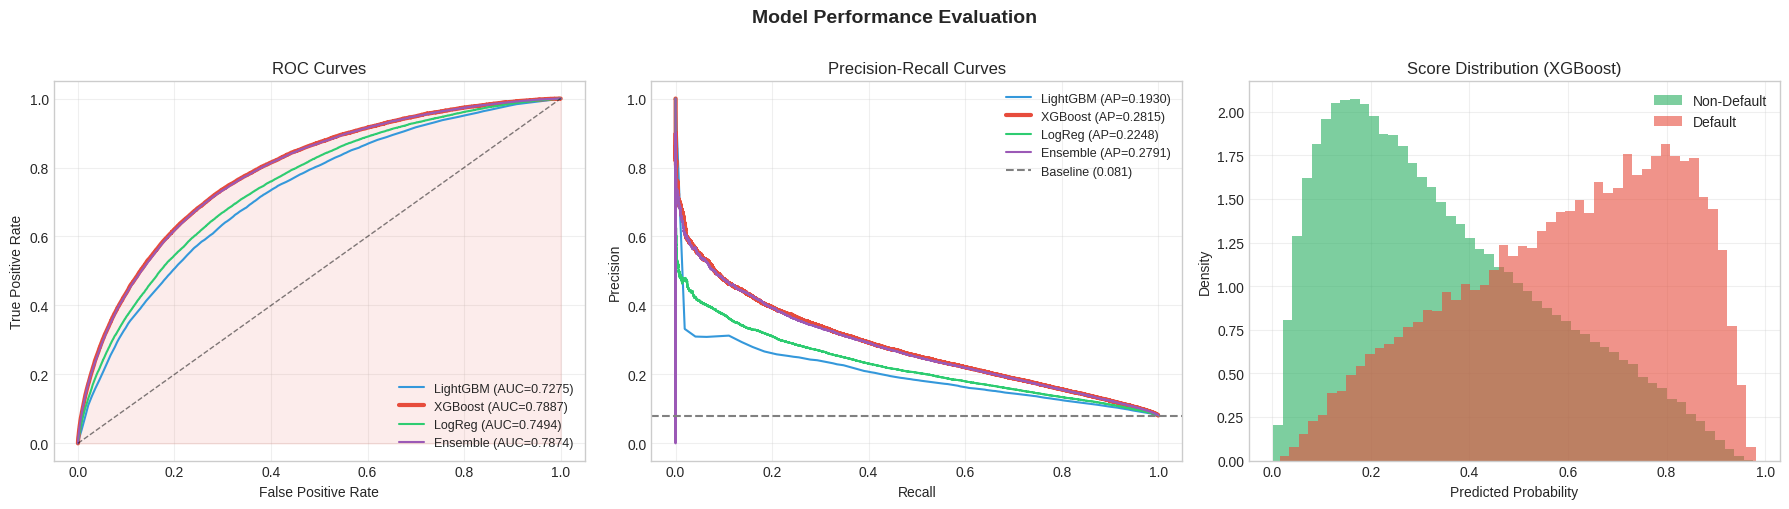

In [29]:
print("=" * 60)
print("EVALUASI MODEL — ROC, PR, SCORE DISTRIBUTION")
print("=" * 60)

model_colors = {'LightGBM': '#3498db', 'XGBoost': '#e74c3c',
                'LogReg': '#2ecc71', 'Ensemble': '#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
for name, color in model_colors.items():
    oof = results[name]['oof']
    fpr, tpr, _ = roc_curve(y, oof)
    auc = results[name]['ROC']
    lw  = 3 if name == best_name else 1.5
    axes[0].plot(fpr, tpr, color=color, linewidth=lw, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5)
axes[0].fill_between(*roc_curve(y, best_oof)[:2], alpha=0.1, color=model_colors[best_name])
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR Curves
for name, color in model_colors.items():
    oof = results[name]['oof']
    prec, rec, _ = precision_recall_curve(y, oof)
    prauc = results[name]['PR']
    lw    = 3 if name == best_name else 1.5
    axes[1].plot(rec, prec, color=color, linewidth=lw, label=f'{name} (AP={prauc:.4f})')
axes[1].axhline(y=y.mean(), color='gray', linestyle='--', label=f'Baseline ({y.mean():.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Score Distribution (Best Model)
for t, color, label in [(0, '#27ae60', 'Non-Default'), (1, '#e74c3c', 'Default')]:
    axes[2].hist(best_oof[y==t], bins=50, alpha=0.6, color=color, label=label, density=True)
axes[2].set(xlabel='Predicted Probability', ylabel='Density',
             title=f'Score Distribution ({best_name})')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Performance Evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


CONFUSION MATRIX (threshold = 0.5)


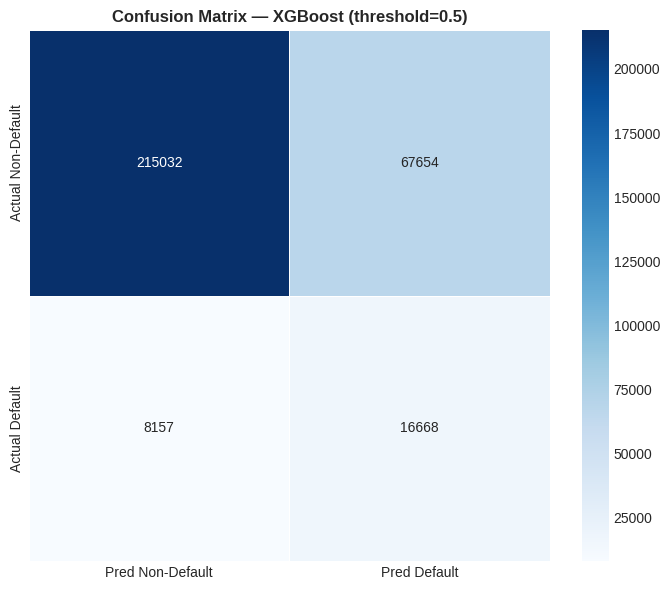


Metrics pada threshold = 0.5:
  ROC-AUC   : 0.7887
  PR-AUC    : 0.2815
  Precision : 0.1977
  Recall    : 0.6714
  F1-Score  : 0.3054
  Brier     : 0.1680

Catatan: Threshold 0.5 mungkin bukan yang optimal untuk kasus ini.
Optimasi threshold dilakukan di Cell 10 berdasarkan tujuan bisnis.



In [30]:
print("=" * 60)
print("CONFUSION MATRIX (threshold = 0.5)")
print("=" * 60)

y_pred_05 = (best_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_05)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Non-Default', 'Pred Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'],
            linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_name} (threshold=0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"""
Metrics pada threshold = 0.5:
  ROC-AUC   : {best_roc:.4f}
  PR-AUC    : {best_prauc:.4f}
  Precision : {precision_score(y, y_pred_05):.4f}
  Recall    : {recall_score(y, y_pred_05):.4f}
  F1-Score  : {f1_score(y, y_pred_05):.4f}
  Brier     : {brier_score_loss(y, best_oof):.4f}

Catatan: Threshold 0.5 mungkin bukan yang optimal untuk kasus ini.
Optimasi threshold dilakukan di Cell 10 berdasarkan tujuan bisnis.
""")


FEATURE IMPORTANCE (LightGBM)
Top 20 Fitur Terpenting:
                       feature  importance
               EXT_SOURCE_PROD           6
         BUREAU_DEBT_RATIO_MAX           3
                EMPLOYED_YEARS           3
         EMPLOYED_TO_AGE_RATIO           2
           INST_PAID_LATE_MEAN           2
     PREV_AMT_DOWN_PAYMENT_SUM           2
           EXT_SOURCE_WEIGHTED           2
         INST_AMT_PAYMENT_MEAN           1
           INST_DAYS_LATE_MEAN           1
          PREV_IS_REFUSED_MEAN           1
                 EXT_LOW_SCORE           1
            CC_UTIL_RATIO_MEAN           1
   PREV_CREDIT_GOODS_RATIO_MAX           1
  PREV_CREDIT_GOODS_RATIO_MEAN           1
                EXT_SOURCE_MAX           1
            CREDIT_GOODS_RATIO           1
          CREDIT_ANNUITY_RATIO           1
BUREAU_CREDIT_DAY_OVERDUE_MEAN           0
 BUREAU_CREDIT_DAY_OVERDUE_MAX           0
        BUREAU_DEBT_RATIO_MEAN           0


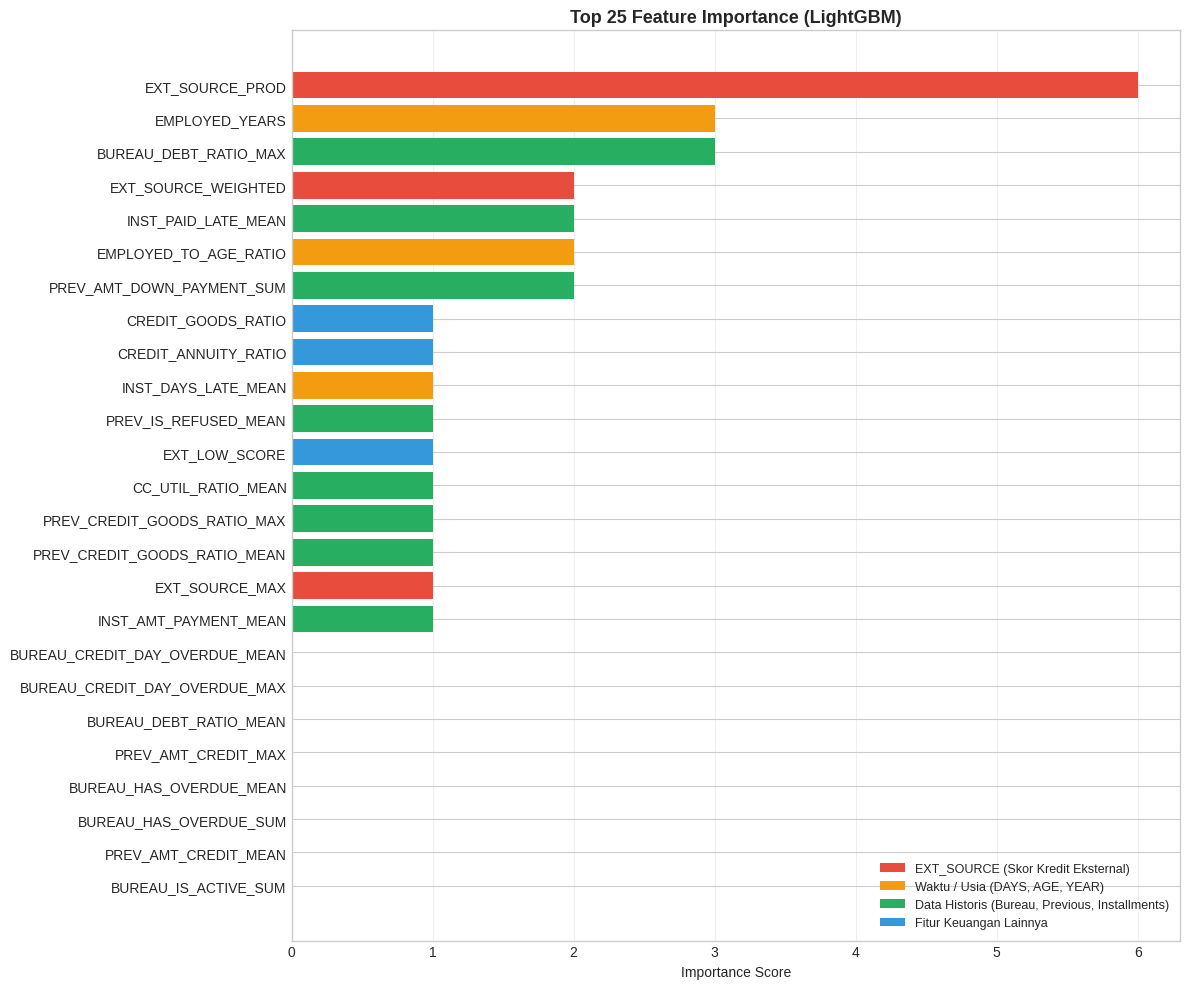

In [31]:
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': X_boost.columns,
    'importance': lgbm_imps
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Fitur Terpenting:")
print(importance_df.head(20).to_string(index=False))

top_df = importance_df.head(25).sort_values('importance')
colors_fi = [
    '#e74c3c' if 'EXT_SOURCE' in f else
    '#f39c12' if any(k in f for k in ['DAYS', 'AGE', 'YEAR']) else
    '#27ae60' if any(k in f for k in ['BUREAU', 'PREV', 'INST', 'POS', 'CC']) else
    '#3498db'
    for f in top_df['feature']
]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(top_df['feature'], top_df['importance'], color=colors_fi)
ax.set_title('Top 25 Feature Importance (LightGBM)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='EXT_SOURCE (Skor Kredit Eksternal)'),
    Patch(facecolor='#f39c12', label='Waktu / Usia (DAYS, AGE, YEAR)'),
    Patch(facecolor='#27ae60', label='Data Historis (Bureau, Previous, Installments)'),
    Patch(facecolor='#3498db', label='Fitur Keuangan Lainnya'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


---
## Cell 11 — Business Insight

Setelah model selesai, kita terjemahkan outputnya ke dalam perspektif bisnis:
1. **Risk Decile Analysis** — segmentasi peminjam berdasarkan skor risiko
2. **Threshold Optimization** — temukan threshold optimal berdasarkan profitabilitas
3. **3-Tier Credit Policy** — kebijakan kredit tiga tingkat


RISK DECILE ANALYSIS
Risk Decile Statistics (D1 = risiko terendah, D10 = tertinggi):
decile  Count  Defaults  Default_Rate     Total_Amount
    D1  30752       257        0.0084 19172552704.0000
    D2  30751       478        0.0155 19214039040.0000
    D3  30751       681        0.0221 19230531584.0000
    D4  30751       936        0.0304 19354109952.0000
    D5  30751      1196        0.0389 19235229696.0000
    D6  30751      1651        0.0537 18761453568.0000
    D7  30751      2246        0.0730 18339786752.0000
    D8  30751      3227        0.1049 17591130112.0000
    D9  30751      4812        0.1565 16733198336.0000
   D10  30751      9341        0.3038 15691787264.0000


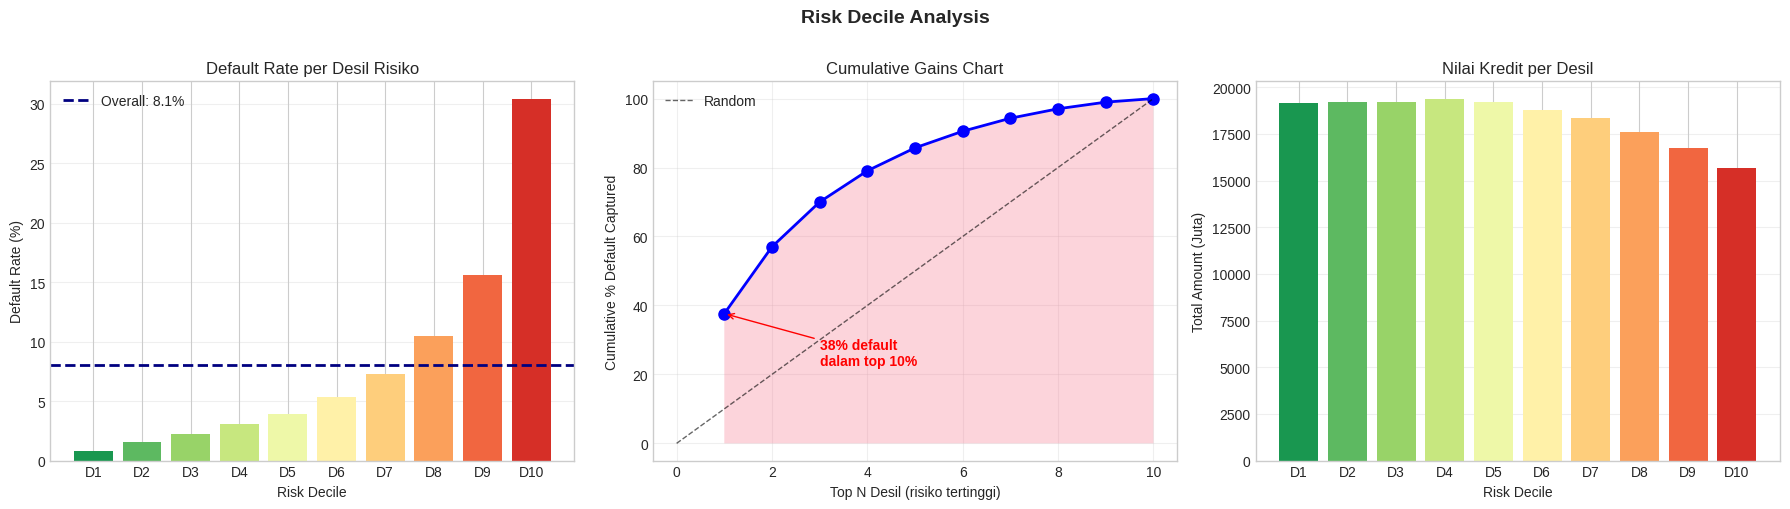


Model menangkap 38% dari total default hanya dengan mereview 10% teratas!


In [32]:
print("=" * 60)
print("RISK DECILE ANALYSIS")
print("=" * 60)

df_analysis = pd.DataFrame({'score': best_oof, 'target': y, 'amount': train_amt})

try:
    df_analysis['decile'] = pd.qcut(df_analysis['score'], 10,
                                     labels=[f'D{i}' for i in range(1, 11)], duplicates='drop')
except:
    df_analysis['decile'] = pd.cut(df_analysis['score'], 10,
                                    labels=[f'D{i}' for i in range(1, 11)])

decile_stats = df_analysis.groupby('decile', observed=True).agg(
    Count=('target', 'count'),
    Defaults=('target', 'sum'),
    Default_Rate=('target', 'mean'),
    Total_Amount=('amount', 'sum')
).reset_index()

print("Risk Decile Statistics (D1 = risiko terendah, D10 = tertinggi):")
print(decile_stats.to_string(index=False))

# Cumulative gains
decile_sorted = decile_stats.sort_values('decile', ascending=False)
decile_sorted['cum_pct'] = decile_sorted['Defaults'].cumsum() / decile_sorted['Defaults'].sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(decile_stats)))

axes[0].bar(decile_stats['decile'].astype(str), decile_stats['Default_Rate']*100, color=bar_colors)
axes[0].axhline(y=y.mean()*100, color='navy', linestyle='--', linewidth=2,
                 label=f'Overall: {y.mean()*100:.1f}%')
axes[0].set(xlabel='Risk Decile', ylabel='Default Rate (%)', title='Default Rate per Desil Risiko')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

x_vals = range(1, len(decile_sorted)+1)
axes[1].plot(x_vals, decile_sorted['cum_pct'].values, 'b-o', linewidth=2, markersize=8)
axes[1].plot([0, 10], [0, 100], 'k--', linewidth=1, alpha=0.6, label='Random')
axes[1].fill_between(x_vals, decile_sorted['cum_pct'].values, alpha=0.3)
top_10_capture = decile_sorted.iloc[0]['cum_pct']
axes[1].annotate(f'{top_10_capture:.0f}% default\ndalam top 10%',
                  xy=(1, top_10_capture), xytext=(3, top_10_capture - 15),
                  arrowprops=dict(arrowstyle='->', color='red'),
                  fontsize=10, color='red', fontweight='bold')
axes[1].set(xlabel='Top N Desil (risiko tertinggi)', ylabel='Cumulative % Default Captured',
             title='Cumulative Gains Chart')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].bar(decile_stats['decile'].astype(str), decile_stats['Total_Amount']/1e6, color=bar_colors)
axes[2].set(xlabel='Risk Decile', ylabel='Total Amount (Juta)', title='Nilai Kredit per Desil')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Risk Decile Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nModel menangkap {top_10_capture:.0f}% dari total default hanya dengan mereview 10% teratas!")


THRESHOLD OPTIMIZATION BERBASIS PROFIT
Parameter bisnis yang digunakan:
  Profit rate (good loan) : 10%
  Loss Given Default      : 40%
  Min approval rate       : 70%
  Baseline profit (tanpa model): $11,424,943,104


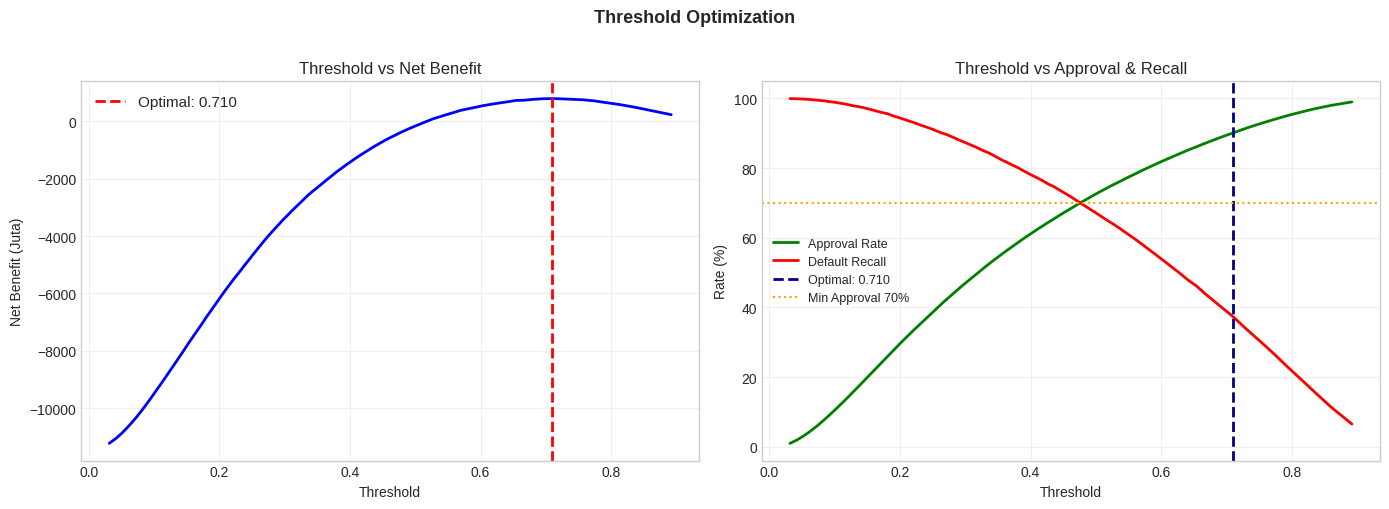


Hasil Threshold Optimization:
  Optimal Threshold : 0.710
  Net Benefit       : $797,104,128
  Approval Rate     : 90.1%
  Default Recall    : 37.4%
  Precision         : 30.5%



In [33]:
print("=" * 60)
print("THRESHOLD OPTIMIZATION BERBASIS PROFIT")
print("=" * 60)

# Parameter bisnis — ditentukan SETELAH melihat data, bukan di awal
# Nilai berikut merupakan asumsi umum industri keuangan Indonesia
PROFIT_RATE = 0.10   # 10% margin pada pinjaman yang lunas
LGD         = 0.40   # 40% Loss Given Default (kerugian jika gagal bayar)
INTEREST    = 0.12   # 12% pendapatan bunga
LOSS_RATE   = 0.80   # 80% kerugian aktual pada default
MIN_APPROVAL = 0.70  # Minimal 70% aplikasi harus disetujui

gain_good     = PROFIT_RATE * train_amt
loss_default  = LGD * train_amt
baseline_profit = np.where(y == 0, gain_good, -loss_default).sum()

print(f"Parameter bisnis yang digunakan:")
print(f"  Profit rate (good loan) : {PROFIT_RATE*100:.0f}%")
print(f"  Loss Given Default      : {LGD*100:.0f}%")
print(f"  Min approval rate       : {MIN_APPROVAL*100:.0f}%")
print(f"  Baseline profit (tanpa model): ${baseline_profit:,.0f}")

thresholds = np.unique(np.quantile(best_oof, np.linspace(0.01, 0.99, 100)))
thresh_results = []
for t in thresholds:
    reject  = best_oof >= t
    approve = ~reject
    model_profit = np.where(approve & (y == 0), gain_good,
                   np.where(approve & (y == 1), -loss_default, 0)).sum()
    thresh_results.append({
        'Threshold'    : t,
        'Net_Benefit'  : model_profit - baseline_profit,
        'Approval_Rate': approve.mean(),
        'Recall'       : recall_score(y, reject.astype(int), zero_division=0),
        'Precision'    : precision_score(y, reject.astype(int), zero_division=0)
    })

thresh_df = pd.DataFrame(thresh_results)
valid     = thresh_df[thresh_df['Approval_Rate'] >= MIN_APPROVAL]
opt_idx   = valid['Net_Benefit'].idxmax() if len(valid) > 0 else thresh_df['Net_Benefit'].idxmax()
opt_thresh = thresh_df.loc[opt_idx, 'Threshold']
opt_row    = thresh_df.loc[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Net_Benefit']/1e6, 'b-', linewidth=2)
axes[0].axvline(x=opt_thresh, color='red', linestyle='--', linewidth=2,
                 label=f'Optimal: {opt_thresh:.3f}')
axes[0].set(xlabel='Threshold', ylabel='Net Benefit (Juta)', title='Threshold vs Net Benefit')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['Threshold'], thresh_df['Approval_Rate']*100, 'g-',
              linewidth=2, label='Approval Rate')
axes[1].plot(thresh_df['Threshold'], thresh_df['Recall']*100, 'r-',
              linewidth=2, label='Default Recall')
axes[1].axvline(x=opt_thresh, color='navy', linestyle='--', linewidth=2,
                 label=f'Optimal: {opt_thresh:.3f}')
axes[1].axhline(y=MIN_APPROVAL*100, color='orange', linestyle=':',
                 label=f'Min Approval {MIN_APPROVAL*100:.0f}%')
axes[1].set(xlabel='Threshold', ylabel='Rate (%)', title='Threshold vs Approval & Recall')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Optimization', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
Hasil Threshold Optimization:
  Optimal Threshold : {opt_thresh:.3f}
  Net Benefit       : ${opt_row['Net_Benefit']:,.0f}
  Approval Rate     : {opt_row['Approval_Rate']:.1%}
  Default Recall    : {opt_row['Recall']:.1%}
  Precision         : {opt_row['Precision']:.1%}
""")


In [57]:
# ─── THRESHOLD CONFIG ─────────────────────────────────────────
tier_low  = opt_thresh * 0.5
tier_high = opt_thresh

print(f"Tier thresholds locked:")
print(f"  tier_low  = {tier_low:.4f}")
print(f"  tier_high = {tier_high:.4f}")

Tier thresholds locked:
  tier_low  = 0.3549
  tier_high = 0.7098


3-TIER CREDIT POLICY
Threshold tier (berdasarkan distribusi skor model):
tier_low  = 0.3549
tier_high = 0.7098
max score = 0.5501

Statistik per Tier:
        tier  Count  Defaults  Default_Rate      Total_Amount  Pct_Apps
AUTO_APPROVE 169610      4364        0.0257 105877995520.0000   55.1558
      REVIEW 107429     11171        0.1040  61900677120.0000   34.9350
      REJECT  30472      9290        0.3049  15545145344.0000    9.9092


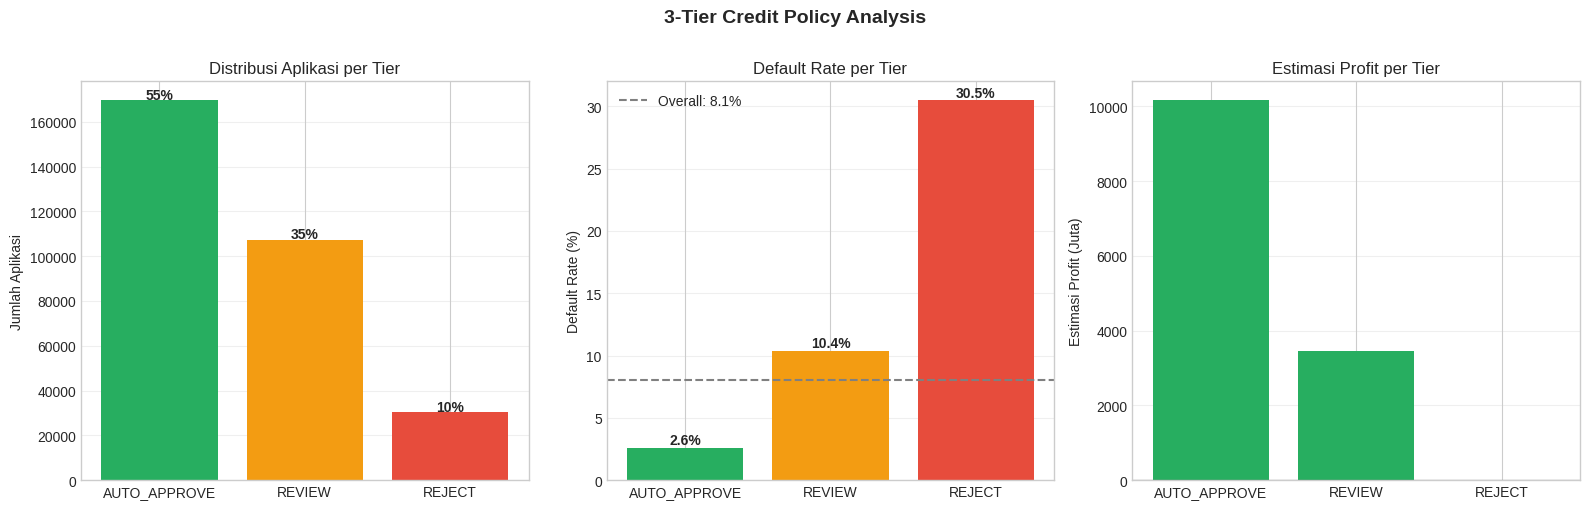


Estimasi Impact:
  Baseline profit       : $  9,289,172,992
  Model-based profit    : $ 13,615,977,670
  Profit lift           : +46.6%



In [58]:
print("=" * 60)
print("3-TIER CREDIT POLICY")
print("=" * 60)

print(f"Threshold tier (berdasarkan distribusi skor model):")
print(f"tier_low  = {tier_low:.4f}")
print(f"tier_high = {tier_high:.4f}")
print(f"max score = {oof_ensemble.max():.4f}")

df_analysis['tier'] = pd.cut(
    df_analysis['score'],
    bins=[-np.inf, tier_low, tier_high, np.inf],
    labels=['AUTO_APPROVE', 'REVIEW', 'REJECT']
)

tier_stats = df_analysis.groupby('tier', observed=True).agg(
    Count=('target', 'count'),
    Defaults=('target', 'sum'),
    Default_Rate=('target', 'mean'),
    Total_Amount=('amount', 'sum')
).reset_index()
tier_stats['Pct_Apps'] = tier_stats['Count'] / tier_stats['Count'].sum() * 100

print("\nStatistik per Tier:")
print(tier_stats.to_string(index=False))

# Estimasi profit per tier
REVIEW_COST = 50  # biaya review manual per aplikasi (asumsi)
tier_profits = {}
for tier in ['AUTO_APPROVE', 'REVIEW', 'REJECT']:
    mask = df_analysis['tier'] == tier
    good   = df_analysis.loc[mask & (df_analysis['target'] == 0), 'amount'].sum()
    bad    = df_analysis.loc[mask & (df_analysis['target'] == 1), 'amount'].sum()
    n_apps = mask.sum()
    if tier == 'AUTO_APPROVE':
        profit = good * INTEREST - bad * LOSS_RATE
    elif tier == 'REVIEW':
        profit = good * INTEREST * 0.9 - bad * LOSS_RATE * 0.5 - n_apps * REVIEW_COST
    else:
        profit = 0
    tier_profits[tier] = profit

total_profit   = sum(tier_profits.values())
tier_baseline  = train_amt[y==0].sum()*INTEREST - train_amt[y==1].sum()*LOSS_RATE
profit_lift    = (total_profit - tier_baseline) / abs(tier_baseline) * 100

tier_colors = {'AUTO_APPROVE': '#27ae60', 'REVIEW': '#f39c12', 'REJECT': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars0 = axes[0].bar(tier_stats['tier'], tier_stats['Count'],
                     color=[tier_colors.get(t, '#999') for t in tier_stats['tier']])
for bar, pct in zip(bars0, tier_stats['Pct_Apps']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                  f'{pct:.0f}%', ha='center', fontweight='bold')
axes[0].set(ylabel='Jumlah Aplikasi', title='Distribusi Aplikasi per Tier')
axes[0].grid(True, alpha=0.3, axis='y')

bars1 = axes[1].bar(tier_stats['tier'], tier_stats['Default_Rate']*100,
                     color=[tier_colors.get(t, '#999') for t in tier_stats['tier']])
axes[1].axhline(y=y.mean()*100, color='gray', linestyle='--', label=f'Overall: {y.mean()*100:.1f}%')
for bar, rate in zip(bars1, tier_stats['Default_Rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{rate*100:.1f}%', ha='center', fontweight='bold')
axes[1].set(ylabel='Default Rate (%)', title='Default Rate per Tier')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

pv = [tier_profits.get(t, 0)/1e6 for t in ['AUTO_APPROVE', 'REVIEW', 'REJECT']]
axes[2].bar(['AUTO_APPROVE', 'REVIEW', 'REJECT'], pv,
             color=['#27ae60' if p >= 0 else '#e74c3c' for p in pv])
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set(ylabel='Estimasi Profit (Juta)', title='Estimasi Profit per Tier')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('3-Tier Credit Policy Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
Estimasi Impact:
  Baseline profit       : ${tier_baseline:>15,.0f}
  Model-based profit    : ${total_profit:>15,.0f}
  Profit lift           : {profit_lift:>+.1f}%
""")


---
## Cell 12 — Rekomendasi Bisnis

Berdasarkan temuan dari EDA, Feature Importance, dan Business Insight, berikut rekomendasi konkret dan terukur untuk Home Credit Indonesia.


In [40]:
# Business metrics calculation
ext2_low_dr  = df_train[df_train['EXT_SOURCE_2'] < 0.3]['TARGET'].mean()
ext2_high_dr = df_train[df_train['EXT_SOURCE_2'] > 0.6]['TARGET'].mean()
young_dr     = df_train[df_train['AGE_YEARS'] < 30]['TARGET'].mean()
senior_dr    = df_train[df_train['AGE_YEARS'] > 50]['TARGET'].mean()
high_cir_dr  = df_train[df_train['CREDIT_INCOME_RATIO'] > 5]['TARGET'].mean()
low_cir_dr   = df_train[df_train['CREDIT_INCOME_RATIO'] < 2]['TARGET'].mean()

print(f"EXT_SOURCE_2 low  (<0.3): {ext2_low_dr*100:.1f}%")
print(f"EXT_SOURCE_2 high (>0.6): {ext2_high_dr*100:.1f}%")
print(f"Age <30 default rate    : {young_dr*100:.1f}%")
print(f"Age >50 default rate    : {senior_dr*100:.1f}%")
print(f"Credit/Income >5x       : {high_cir_dr*100:.1f}%")
print(f"Credit/Income <2x       : {low_cir_dr*100:.1f}%")

EXT_SOURCE_2 low  (<0.3): 15.9%
EXT_SOURCE_2 high (>0.6): 4.6%
Age <30 default rate    : 11.5%
Age >50 default rate    : 5.7%
Credit/Income >5x       : 7.4%
Credit/Income <2x       : 7.5%


## Rekomendasi Bisnis

### 1. Prioritaskan Skor Kredit Eksternal (EXT_SOURCE)
EXT_SOURCE_2 dan EXT_SOURCE_3 adalah dua fitur paling penting dalam model berdasarkan SHAP value dan feature importance. Peminjam dengan EXT_SOURCE_2 rendah (< 0.3) memiliki default rate **15.9%**, jauh lebih tinggi dibanding peminjam dengan EXT_SOURCE_2 tinggi (> 0.6) yang hanya **4.6%** — selisih 11.3 poin persentase.

**Rekomendasi aksi:**
- Wajibkan data dari minimal 2 dari 3 sumber biro kredit eksternal
- Tetapkan EXT_SOURCE_WEIGHTED ≥ 0.4 sebagai syarat minimum AUTO_APPROVE
- Tandai peminjam yang ketiga EXT_SOURCE-nya kosong untuk review manual

### 2. Kebijakan Kredit Berbasis Usia
Peminjam berusia di bawah 30 tahun memiliki default rate **11.5%**, jauh di atas rata-rata portofolio 8.1%. Sebaliknya, peminjam berusia di atas 50 tahun hanya **5.7%**. Artinya usia muda merupakan faktor risiko yang signifikan.

**Rekomendasi aksi:**
- Batasi CREDIT_INCOME_RATIO maksimal 2x untuk peminjam di bawah 30 tahun
- Terapkan proses persetujuan cepat (< 24 jam) untuk peminjam di atas 50 tahun dengan skor EXT_SOURCE yang baik

### 3. Rasio Kredit terhadap Pendapatan Bukan Indikator Tunggal
Menariknya, CREDIT_INCOME_RATIO tidak menunjukkan perbedaan yang berarti — default rate untuk rasio > 5x adalah **7.4%** vs **7.5%** untuk rasio < 2x. Ini menunjukkan bahwa rasio kredit/pendapatan saja tidak cukup untuk menilai risiko peminjam.

**Rekomendasi aksi:**
- Jangan gunakan CREDIT_INCOME_RATIO sebagai satu-satunya kriteria penolakan
- Gunakan sebagai sinyal tambahan di dalam tier REVIEW, dikombinasikan dengan skor EXT_SOURCE

### 4. Implementasi 3-Tier Credit Policy
Berdasarkan threshold optimal yang dihitung dari profit optimization (opt_thresh = 0.7098):

| Tier | Rentang Skor | Default Rate | Proporsi |
|---|---|---|---|
| AUTO_APPROVE | < 0.355 | 2.6% | 55.2% |
| REVIEW | 0.355 – 0.710 | 10.4% | 34.9% |
| REJECT | > 0.710 | 30.5% | 9.9% |

Estimasi peningkatan profit dibanding baseline tanpa model: **+46.6%**

In [41]:
# ── Tambahan Library untuk Upgrade ───────────────────────────
# Jalankan cell ini setelah Cell 1 (Setup & Import)
try:
    import shap
    print("SHAP sudah terinstall")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "-q"])
    import shap
    print("SHAP berhasil diinstall")

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
import matplotlib.ticker as mticker
print("Library upgrade siap.")


SHAP sudah terinstall
Library upgrade siap.


---
## Cell 14 — SHAP Values: Explainability Model

> **Mengapa SHAP penting?**
> Tidak cukup dengan angka AUC saja.
> SHAP (SHapley Additive exPlanations) menjelaskan *mengapa* model membuat keputusan tertentu —
> fitur mana yang mendorong prediksi naik atau turun untuk setiap individu peminjam.
> Ini adalah standar industri untuk Explainable AI (XAI) di bidang kredit & keuangan.


In [42]:
print("=" * 60)
print("SHAP VALUES — EXPLAINABILITY ANALYSIS")
print("=" * 60)

# ── 1. SHAP Global Explainability (Beeswarm + Bar) ────────────
print("\nMenghitung SHAP values untuk LightGBM...")
print("(Proses ini mungkin membutuhkan beberapa menit pada dataset besar)\\n")

# Sample 3000 baris untuk efisiensi di Colab
sample_size = min(3000, len(X_boost))
np.random.seed(42)
shap_idx    = np.random.choice(len(X_boost), sample_size, replace=False)
X_shap_sample = X_boost.iloc[shap_idx].copy().fillna(-999)

# Gunakan LightGBM model fold terakhir (sudah ada lgbm_imps dari Cell 9)
# Latih ulang model dengan data penuh untuk SHAP
print("Melatih model SHAP (single fold, data penuh)...")
lgbm_shap_model = LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=100, reg_alpha=0.1, reg_lambda=0.1,
    scale_pos_weight=pos_weight, random_state=42, n_jobs=2, verbose=-1
)
lgbm_shap_model.fit(X_boost.fillna(-999), y)
print("Model SHAP selesai dilatih.")

# Hitung SHAP values
explainer   = shap.TreeExplainer(lgbm_shap_model)
shap_values = explainer.shap_values(X_shap_sample)

# Untuk LightGBM binary classification, shap_values mungkin list [neg, pos]
if isinstance(shap_values, list):
    sv = shap_values[1]   # kelas positif (DEFAULT)
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")
print(f"Sample size: {sample_size:,} baris")



SHAP VALUES — EXPLAINABILITY ANALYSIS

Menghitung SHAP values untuk LightGBM...
(Proses ini mungkin membutuhkan beberapa menit pada dataset besar)\n
Melatih model SHAP (single fold, data penuh)...
Model SHAP selesai dilatih.
SHAP values shape: (3000, 274)
Sample size: 3,000 baris



Membuat SHAP Beeswarm Plot (Top 20 fitur)...


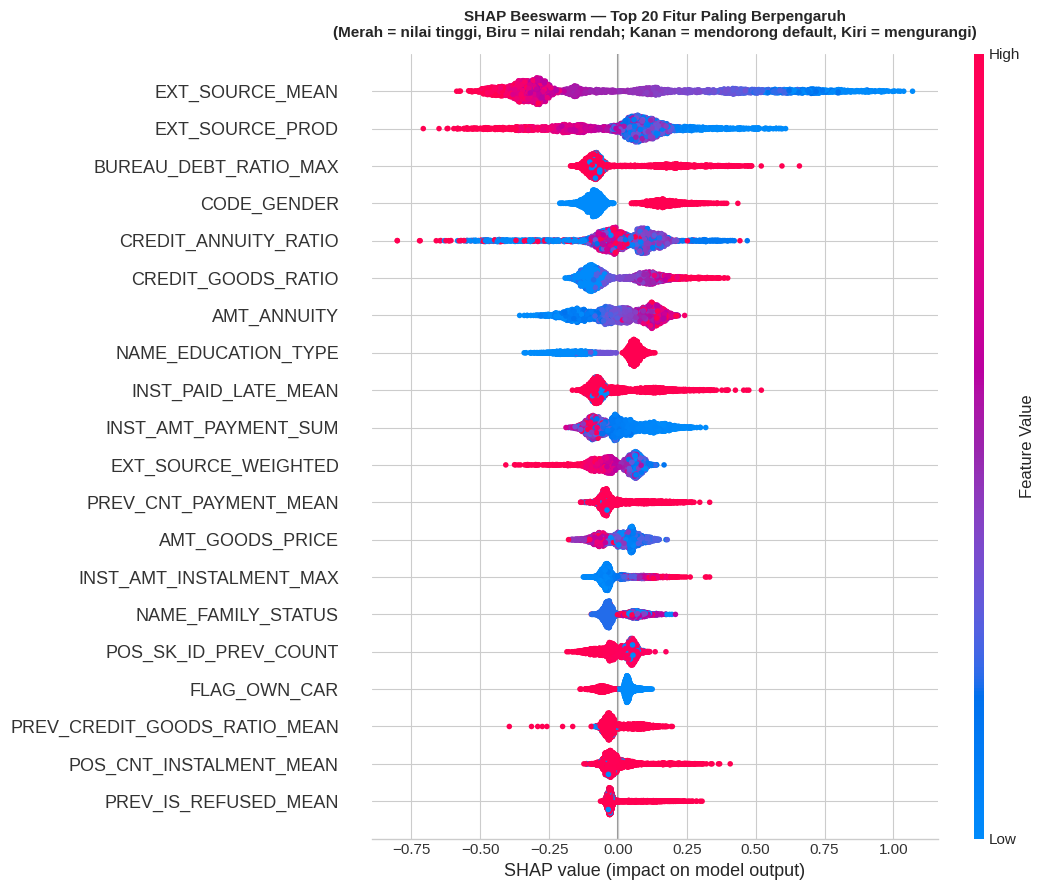

  → Disimpan sebagai shap_beeswarm.png


In [43]:

# ── Plot 1: Beeswarm (SHAP Summary Plot) ─────────────────────
print("\nMembuat SHAP Beeswarm Plot (Top 20 fitur)...")
plt.figure(figsize=(11, 9))
shap.summary_plot(
    sv, X_shap_sample,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar_label='Feature Value'
)
plt.title("SHAP Beeswarm — Top 20 Fitur Paling Berpengaruh\n"
          "(Merah = nilai tinggi, Biru = nilai rendah; Kanan = mendorong default, Kiri = mengurangi)",
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Disimpan sebagai shap_beeswarm.png")


Membuat SHAP Bar Plot...


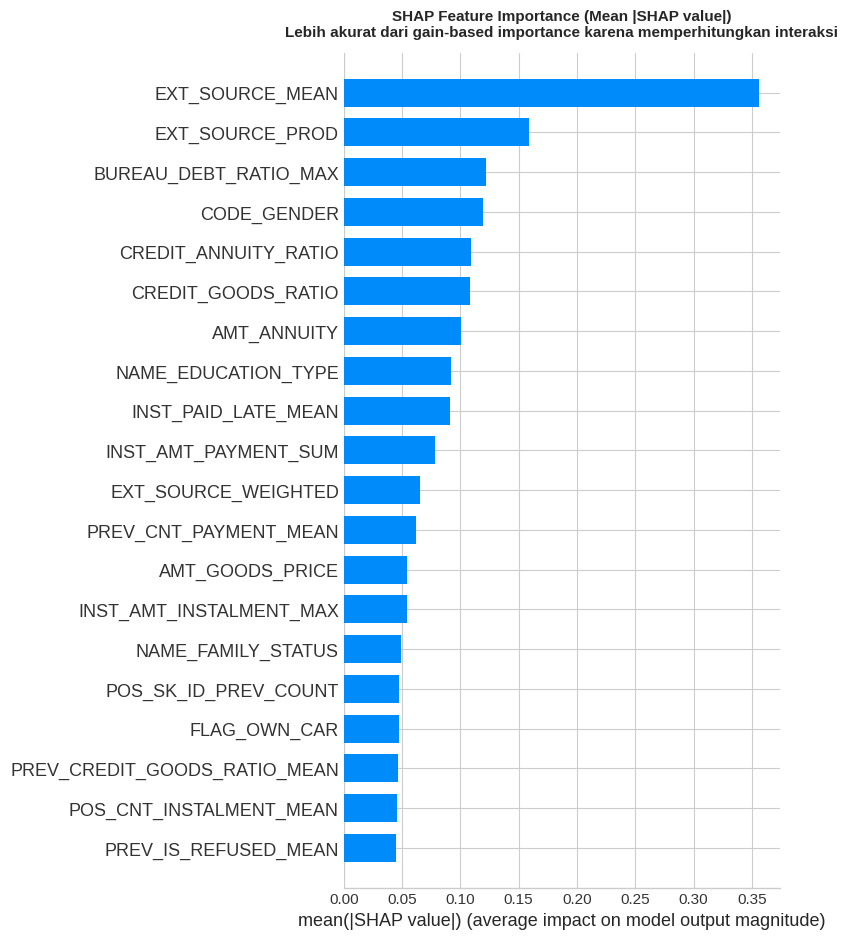

  → Disimpan sebagai shap_bar.png


In [44]:

# ── Plot 2: SHAP Bar (Mean Absolute) ─────────────────────────
print("\nMembuat SHAP Bar Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_shap_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)\n"
          "Lebih akurat dari gain-based importance karena memperhitungkan interaksi",
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Disimpan sebagai shap_bar.png")


SHAP DEPENDENCE PLOT — EXT_SOURCE_2


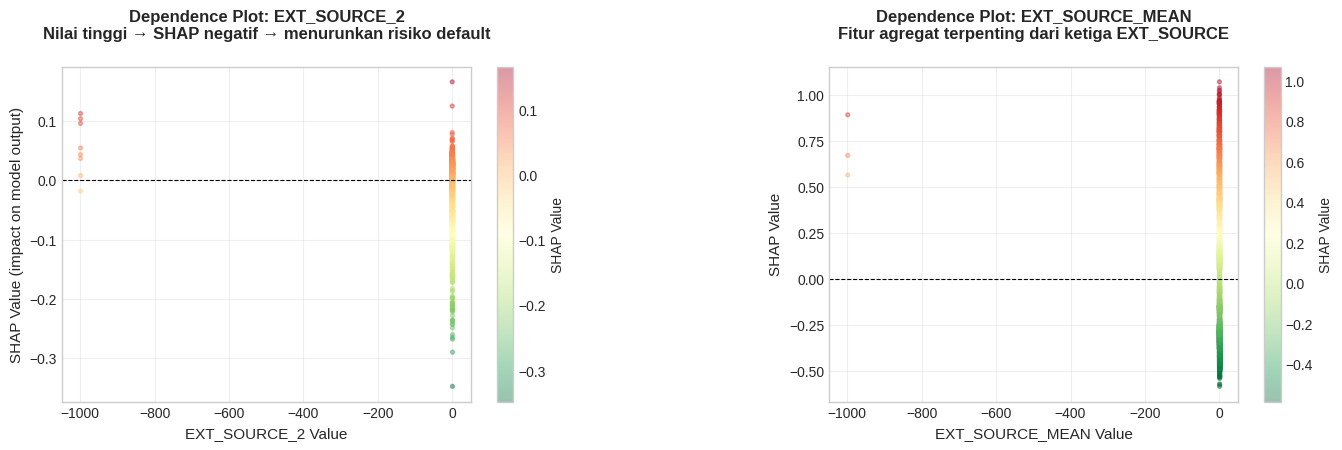

  → Disimpan sebagai shap_dependence.png


In [84]:
# ── Plot 3: SHAP Dependence Plot (EXT_SOURCE_2) ───────────────
print("=" * 60)
print("SHAP DEPENDENCE PLOT — EXT_SOURCE_2")
print("=" * 60)

ext2_idx = list(X_shap_sample.columns).index('EXT_SOURCE_2') if 'EXT_SOURCE_2' in X_shap_sample.columns else None
if ext2_idx is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Manual dependence plot (lebih fleksibel dari shap.dependence_plot)
    ext2_vals  = X_shap_sample['EXT_SOURCE_2'].values
    ext2_shaps = sv[:, ext2_idx]

    sc = axes[0].scatter(ext2_vals, ext2_shaps, c=ext2_shaps, cmap='RdYlGn_r',
                          alpha=0.4, s=8)
    plt.colorbar(sc, ax=axes[0], label='SHAP Value')
    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_xlabel('EXT_SOURCE_2 Value', fontsize=11)
    axes[0].set_ylabel('SHAP Value (impact on model output)', fontsize=11)
    axes[0].set_title('Dependence Plot: EXT_SOURCE_2\n'
                       'Nilai tinggi → SHAP negatif → menurunkan risiko default',
                       fontweight='bold',
                       pad='20')
    axes[0].grid(True, alpha=0.3)

    # EXT_SOURCE_MEAN dependence
    if 'EXT_SOURCE_MEAN' in X_shap_sample.columns:
        mean_idx  = list(X_shap_sample.columns).index('EXT_SOURCE_MEAN')
        mean_vals = X_shap_sample['EXT_SOURCE_MEAN'].values
        mean_shap = sv[:, mean_idx]
        sc2 = axes[1].scatter(mean_vals, mean_shap, c=mean_shap, cmap='RdYlGn_r',
                               alpha=0.4, s=8)
        plt.colorbar(sc2, ax=axes[1], label='SHAP Value')
        axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[1].set_xlabel('EXT_SOURCE_MEAN Value', fontsize=11)
        axes[1].set_ylabel('SHAP Value', fontsize=11)
        axes[1].set_title('Dependence Plot: EXT_SOURCE_MEAN\n'
                           'Fitur agregat terpenting dari ketiga EXT_SOURCE',
                           fontweight='bold',
                           pad='20')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout(pad=2.5)
    plt.subplots_adjust(wspace=0.5)
    plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  → Disimpan sebagai shap_dependence.png")


SHAP Individual Explanation — Contoh Kasus Default & Non-Default


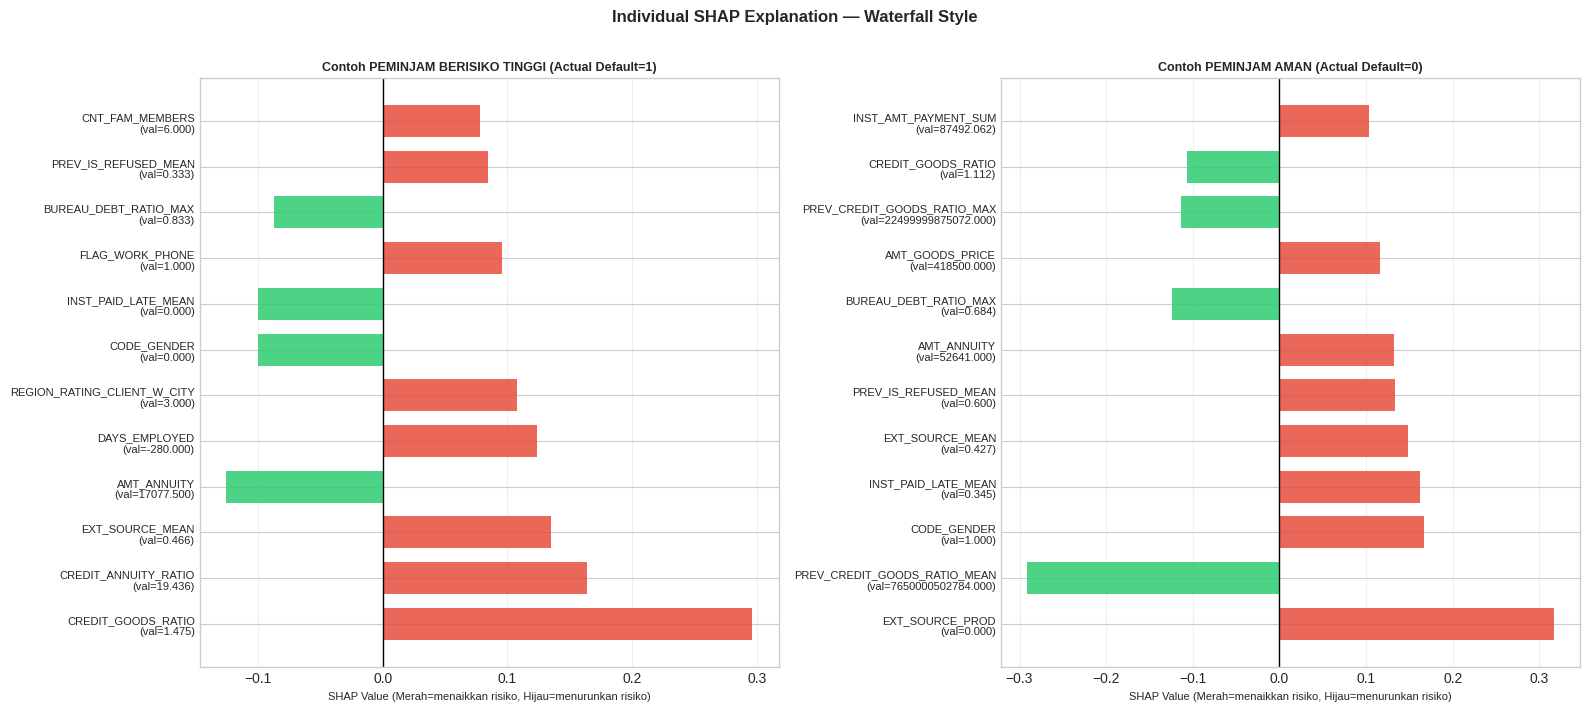

  → Disimpan sebagai shap_individual.png

Top 10 fitur by SHAP:
              feature  mean_abs_shap  rank
      EXT_SOURCE_MEAN         0.3562     1
      EXT_SOURCE_PROD         0.1589     2
BUREAU_DEBT_RATIO_MAX         0.1218     3
          CODE_GENDER         0.1198     4
 CREDIT_ANNUITY_RATIO         0.1091     5
   CREDIT_GOODS_RATIO         0.1087     6
          AMT_ANNUITY         0.1004     7
  NAME_EDUCATION_TYPE         0.0921     8
  INST_PAID_LATE_MEAN         0.0913     9
 INST_AMT_PAYMENT_SUM         0.0779    10

  → shap_importance.csv disimpan untuk Power BI


In [80]:
# ── Plot 4: SHAP Individual Explanation (Waterfall) ───────────
print("\nSHAP Individual Explanation — Contoh Kasus Default & Non-Default")

# Pilih 1 contoh default dan 1 non-default
default_indices    = np.where(y[shap_idx] == 1)[0]
nondefault_indices = np.where(y[shap_idx] == 0)[0]

if len(default_indices) > 0 and len(nondefault_indices) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax_idx, (sample_i, label) in enumerate([
        (default_indices[0],    "Contoh PEMINJAM BERISIKO TINGGI (Actual Default=1)"),
        (nondefault_indices[0], "Contoh PEMINJAM AMAN (Actual Default=0)")
    ]):
        top_n    = 12
        shap_i   = sv[sample_i]
        feat_i   = X_shap_sample.iloc[sample_i]

        abs_shap = np.abs(shap_i)
        top_feat_idx = np.argsort(abs_shap)[-top_n:][::-1]

        features_top = X_shap_sample.columns[top_feat_idx]
        shap_top     = shap_i[top_feat_idx]
        vals_top     = feat_i.values[top_feat_idx]

        colors = ['#e74c3c' if s > 0 else '#2ecc71' for s in shap_top]
        y_pos  = range(top_n)
        ax     = axes[ax_idx]
        bars   = ax.barh(list(y_pos), shap_top, color=colors, alpha=0.85, height=0.7)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels([f"{f}\n(val={v:.3f})" for f, v in zip(features_top, vals_top)],
                            fontsize=8)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(label, fontsize=9, fontweight='bold', wrap=True)
        ax.set_xlabel("SHAP Value (Merah=menaikkan risiko, Hijau=menurunkan risiko)", fontsize=8)
        ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle("Individual SHAP Explanation — Waterfall Style",
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('shap_individual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  → Disimpan sebagai shap_individual.png")

# Export SHAP summary untuk Power BI
shap_importance_df = pd.DataFrame({
    'feature': X_shap_sample.columns,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_importance_df['rank'] = range(1, len(shap_importance_df)+1)
shap_importance_df.to_csv('shap_importance.csv', index=False)
print(f"\nTop 10 fitur by SHAP:")
print(shap_importance_df.head(10).to_string(index=False))
print("\n  → shap_importance.csv disimpan untuk Power BI")


---
## Cell 15 — Calibration Curve: Apakah Skor Probabilitas Dapat Dipercaya?

> **Mengapa Calibration penting?**
> Model dengan ROC-AUC tinggi belum tentu menghasilkan probabilitas yang *akurat*.
> Calibration memastikan bahwa skor 0.3 benar-benar berarti "30% kemungkinan default".
> Ini sangat krusial untuk penetapan suku bunga, pricing risiko, dan kebijakan kredit.


CALIBRATION CURVE ANALYSIS


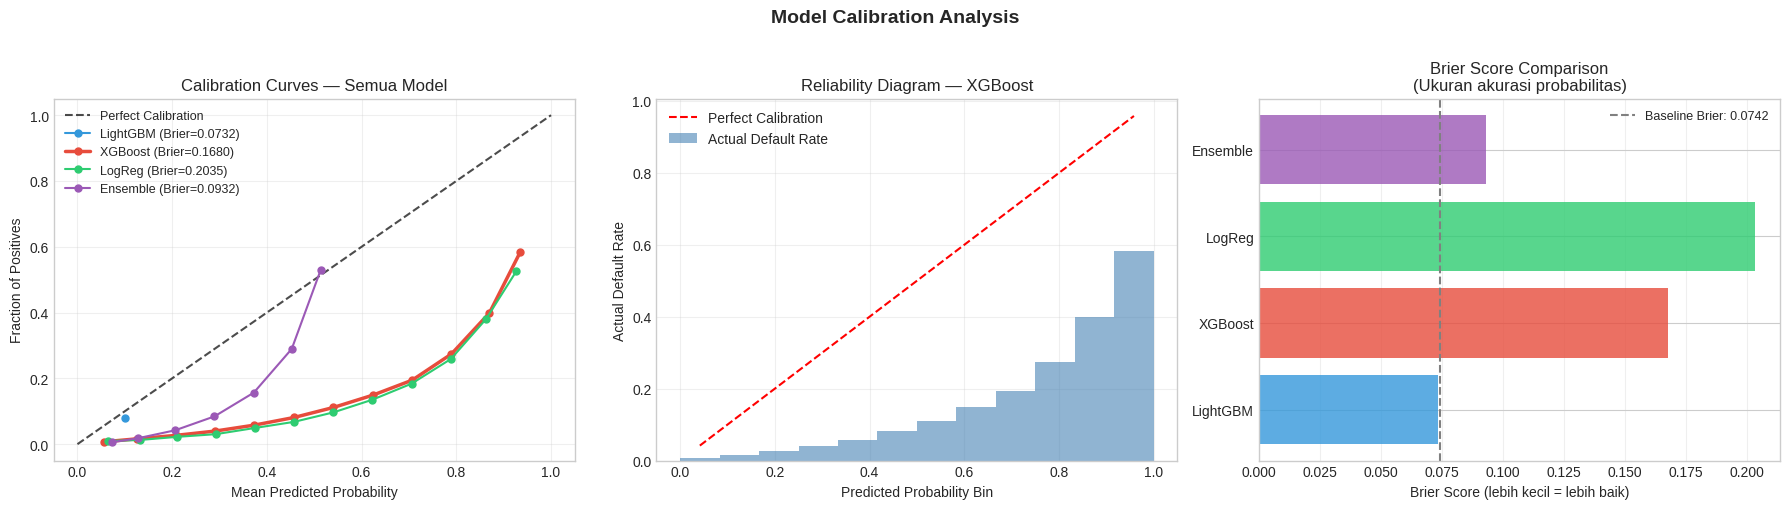


Brier Scores (lower = better probability calibration):
  LightGBM    : 0.0732  (Brier Skill Score: 0.0131)
  Ensemble    : 0.0932  (Brier Skill Score: -0.2554)
  XGBoost     : 0.1680  (Brier Skill Score: -1.2632)
  LogReg      : 0.2035  (Brier Skill Score: -1.7427)

Baseline Brier (no model): 0.0742

INTERPRETASI:
  • Brier Score = 0.0  → perfect (semua probabilitas akurat)
  • Brier Score = baseline → sama dengan naive model
  • Brier Skill Score > 0 → lebih baik dari baseline
  • Kurva di atas garis diagonal → model UNDER-confident (terlalu konservatif)
  • Kurva di bawah garis diagonal → model OVER-confident

POST-HOC CALIBRATION: Platt Scaling pada Ensemble

  Sebelum Kalibrasi: AUC=0.7874, Brier=0.0932
  Setelah Kalibrasi: AUC=0.7874,  Brier=0.0661
  Improvement Brier: 2.71%

Note: Kalibrasi Platt Scaling menjaga AUC (ranking) tetap sama
      tetapi membuat probabilitas lebih akurat secara absolut.
      Gunakan oof_calibrated untuk penetapan pricing risiko aktual.

  → calibrat

In [46]:
print("=" * 60)
print("CALIBRATION CURVE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_oof_dict = {
    'LightGBM': oof_lgbm,
    'XGBoost' : oof_xgb,
    'LogReg'  : oof_lr,
    'Ensemble': oof_ensemble
}
model_colors_calib = {
    'LightGBM': '#3498db', 'XGBoost': '#e74c3c',
    'LogReg': '#2ecc71', 'Ensemble': '#9b59b6'
}
n_bins = 12
brier_scores = {}

# ── Plot 1: Calibration Curves semua model ────────────────────
axes[0].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Perfect Calibration', alpha=0.7)
for name, oof in model_oof_dict.items():
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=n_bins, strategy='uniform')
    brier = brier_score_loss(y, oof)
    brier_scores[name] = brier
    lw = 2.5 if name == best_name else 1.5
    axes[0].plot(mean_pred, frac_pos, 'o-', color=model_colors_calib[name],
                  linewidth=lw, markersize=5, label=f'{name} (Brier={brier:.4f})')

axes[0].set(xlabel='Mean Predicted Probability', ylabel='Fraction of Positives',
             title='Calibration Curves — Semua Model')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Distribusi skor dengan reliability diagram ────────
bins    = np.linspace(0, 1, n_bins+1)
bin_mid = (bins[:-1] + bins[1:]) / 2
frac_pos_best, mean_pred_best = calibration_curve(y, best_oof, n_bins=n_bins, strategy='uniform')

axes[1].bar(bin_mid, frac_pos_best, width=1/n_bins, alpha=0.6,
             color='steelblue', label='Actual Default Rate')
axes[1].plot(bin_mid, bin_mid, 'r--', linewidth=1.5, label='Perfect Calibration')
axes[1].set(xlabel='Predicted Probability Bin', ylabel='Actual Default Rate',
             title=f'Reliability Diagram — {best_name}')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Brier Score comparison bar chart
axes[2].barh(list(brier_scores.keys()), list(brier_scores.values()),
              color=[model_colors_calib[m] for m in brier_scores.keys()], alpha=0.8)
axes[2].axvline(x=y.mean()*(1-y.mean()), color='gray', linestyle='--',
                 linewidth=1.5, label=f'Baseline Brier: {y.mean()*(1-y.mean()):.4f}')
axes[2].set(xlabel='Brier Score (lebih kecil = lebih baik)',
             title='Brier Score Comparison\n(Ukuran akurasi probabilitas)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Model Calibration Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBrier Scores (lower = better probability calibration):")
for name, bs in sorted(brier_scores.items(), key=lambda x: x[1]):
    baseline = y.mean() * (1 - y.mean())
    skill    = 1 - bs/baseline
    print(f"  {name:<12}: {bs:.4f}  (Brier Skill Score: {skill:.4f})")

print(f"\nBaseline Brier (no model): {y.mean()*(1-y.mean()):.4f}")
print("""
INTERPRETASI:
  • Brier Score = 0.0  → perfect (semua probabilitas akurat)
  • Brier Score = baseline → sama dengan naive model
  • Brier Skill Score > 0 → lebih baik dari baseline
  • Kurva di atas garis diagonal → model UNDER-confident (terlalu konservatif)
  • Kurva di bawah garis diagonal → model OVER-confident
""")

# ── Platt Scaling Calibration pada Ensemble ───────────────────
print("=" * 60)
print("POST-HOC CALIBRATION: Platt Scaling pada Ensemble")
print("=" * 60)

from sklearn.linear_model import LogisticRegression as LR_calib
from sklearn.model_selection import cross_val_predict

platt = LR_calib(C=1.0, max_iter=1000)
oof_calibrated = cross_val_predict(
    platt, oof_ensemble.reshape(-1, 1), y,
    cv=5, method='predict_proba'
)[:, 1]

brier_before   = brier_score_loss(y, oof_ensemble)
brier_after    = brier_score_loss(y, oof_calibrated)
auc_before     = roc_auc_score(y, oof_ensemble)
auc_after      = roc_auc_score(y, oof_calibrated)

print(f"\n  Sebelum Kalibrasi: AUC={auc_before:.4f}, Brier={brier_before:.4f}")
print(f"  Setelah Kalibrasi: AUC={auc_after:.4f},  Brier={brier_after:.4f}")
print(f"  Improvement Brier: {(brier_before - brier_after)*100:.2f}%")
print("""
Note: Kalibrasi Platt Scaling menjaga AUC (ranking) tetap sama
      tetapi membuat probabilitas lebih akurat secara absolut.
      Gunakan oof_calibrated untuk penetapan pricing risiko aktual.
""")

# Export calibration data untuk Power BI
calib_df = pd.DataFrame({
    'SK_ID_CURR'        : train_ids.values,
    'TARGET'            : y,
    'SCORE_RAW'         : best_oof,
    'SCORE_CALIBRATED'  : oof_calibrated,
    'SCORE_LGBM'        : oof_lgbm,
    'SCORE_XGB'         : oof_xgb,
    'SCORE_LR'          : oof_lr,
    'SCORE_ENSEMBLE'    : oof_ensemble,
})
calib_df.to_csv('calibration_scores.csv', index=False)
print("  → calibration_scores.csv disimpan untuk Power BI")


In [96]:
# ── NILAI UNTUK POWER BI PAGE 4 ───────────────────────────────
baseline_brier = y.mean() * (1 - y.mean())
brier_best     = brier_score_loss(y, oof_calibrated)  # ← ganti dari best_oof
brier_skill    = 1 - (brier_best / baseline_brier)

print(f"Brier Score (calibrated): {brier_best:.4f}")
print(f"Brier Skill (calibrated): {brier_skill:.4f}")
top_shap_feat  = shap_importance_df.iloc[0]['feature']

print("NILAI UNTUK ENTER DATA MANUAL DI POWER BI")
print(f"  Total Features  : {X_boost.shape[1]}")
print(f"  Top Feature SHAP: {top_shap_feat}")
print(f"  Brier Score     : {brier_best:.4f}")
print(f"  Brier Skill     : {brier_skill:.4f}")

# Calibration curve values
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y, best_oof, n_bins=10, strategy='quantile')
print("\nCalibration table (copy ke Enter Data Power BI):")
print(f"{'Bin':<8} {'Ensemble_Actual':<18} {'Perfect'}")
for mp, fp in zip(mean_pred, frac_pos):
    print(f"  {mp:.3f}    {fp:.4f}              {mp:.3f}")

Brier Score (calibrated): 0.0661
Brier Skill (calibrated): 0.1097
NILAI UNTUK ENTER DATA MANUAL DI POWER BI
  Total Features  : 274
  Top Feature SHAP: EXT_SOURCE_MEAN
  Brier Score     : 0.0661
  Brier Skill     : 0.1097

Calibration table (copy ke Enter Data Power BI):
Bin      Ensemble_Actual    Perfect
  0.064    0.0084              0.064
  0.124    0.0155              0.124
  0.176    0.0221              0.176
  0.230    0.0304              0.230
  0.288    0.0389              0.288
  0.354    0.0537              0.354
  0.432    0.0730              0.432
  0.525    0.1049              0.525
  0.640    0.1565              0.640
  0.801    0.3038              0.801


In [104]:
print(shap_importance_df.head(15))

                    feature  mean_abs_shap  rank
0           EXT_SOURCE_MEAN         0.3562     1
1           EXT_SOURCE_PROD         0.1589     2
2     BUREAU_DEBT_RATIO_MAX         0.1218     3
3               CODE_GENDER         0.1198     4
4      CREDIT_ANNUITY_RATIO         0.1091     5
5        CREDIT_GOODS_RATIO         0.1087     6
6               AMT_ANNUITY         0.1004     7
7       NAME_EDUCATION_TYPE         0.0921     8
8       INST_PAID_LATE_MEAN         0.0913     9
9      INST_AMT_PAYMENT_SUM         0.0779    10
10      EXT_SOURCE_WEIGHTED         0.0653    11
11    PREV_CNT_PAYMENT_MEAN         0.0623    12
12          AMT_GOODS_PRICE         0.0542    13
13  INST_AMT_INSTALMENT_MAX         0.0539    14
14       NAME_FAMILY_STATUS         0.0487    15


In [105]:
print(fi_shap_df[['Feature', 'LGBM_Importance', 'SHAP_Importance']].head(10))
print(fi_shap_df['SHAP_Importance'].isna().sum(), "fitur tanpa SHAP value")

                     Feature  LGBM_Importance  SHAP_Importance
0            EXT_SOURCE_PROD                6           0.1589
1      BUREAU_DEBT_RATIO_MAX                3           0.1218
2             EMPLOYED_YEARS                3           0.0279
3      EMPLOYED_TO_AGE_RATIO                2           0.0389
4        INST_PAID_LATE_MEAN                2           0.0913
5  PREV_AMT_DOWN_PAYMENT_SUM                2           0.0320
6        EXT_SOURCE_WEIGHTED                2           0.0653
7      INST_AMT_PAYMENT_MEAN                1           0.0138
8        INST_DAYS_LATE_MEAN                1           0.0431
9       PREV_IS_REFUSED_MEAN                1           0.0452
0 fitur tanpa SHAP value


---
## Cell 16 — Export Datasets untuk Power BI Dashboard

> Semua file di bawah ini dirancang untuk di-import langsung ke Power BI.
> Setiap file merupakan tabel terpisah yang bisa di-*relationship* di Power Query.


In [113]:
print("EXPORT DATASETS UNTUK POWER BI DASHBOARD")

# ───────────────────────────────────────────────────────────────
# TABLE 1: applicant_profile.csv
# ───────────────────────────────────────────────────────────────
profile_cols = ['SK_ID_CURR', 'TARGET', 'CODE_GENDER', 'FLAG_OWN_CAR',
                'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
                'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                'NAME_INCOME_TYPE', 'OCCUPATION_TYPE',
                'ORGANIZATION_TYPE', 'REGION_RATING_CLIENT']

pbi_profile_cols = [c for c in profile_cols if c in df_train.columns]

eng_cols = ['AGE_YEARS', 'EMPLOYED_YEARS', 'CREDIT_INCOME_RATIO',
            'ANNUITY_INCOME_RATIO', 'PAYMENT_BURDEN', 'DOWNPAYMENT_RATIO',
            'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED',
            'YOUNG_HIGH_CREDIT', 'EXT_LOW_SCORE', 'HIGH_CREDIT_INCOME',
            'DAYS_EMPLOYED_ANOM', 'DOCS_SUBMITTED_COUNT']
eng_cols = [c for c in eng_cols if c in df_train.columns]

profile_df = df_train[pbi_profile_cols + eng_cols].copy()

if 'CODE_GENDER' in profile_df.columns:
    profile_df['GENDER_LABEL'] = profile_df['CODE_GENDER'].map({1: 'Male', 0: 'Female'})
if 'FLAG_OWN_CAR' in profile_df.columns:
    profile_df['OWN_CAR_LABEL'] = profile_df['FLAG_OWN_CAR'].map({1: 'Yes', 0: 'No'})
if 'FLAG_OWN_REALTY' in profile_df.columns:
    profile_df['OWN_REALTY_LABEL'] = profile_df['FLAG_OWN_REALTY'].map({1: 'Yes', 0: 'No'})
profile_df['TARGET_LABEL'] = profile_df['TARGET'].map({0: 'Non-Default', 1: 'Default'})

if 'AGE_YEARS' in profile_df.columns:
    profile_df['AGE_GROUP'] = pd.cut(
        profile_df['AGE_YEARS'],
        bins=[0, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100],
        labels=['18-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '65+']
    ).astype(str)

profile_df.to_csv('pbi_applicant_profile.csv', index=False)
print(f"  TABLE 1 — pbi_applicant_profile.csv : {profile_df.shape}  ✓")


# ───────────────────────────────────────────────────────────────
# TABLE 2: risk_scoring.csv
# CREDIT_TIER pakai oof_ensemble langsung (konsisten dengan tier_stats)
# ───────────────────────────────────────────────────────────────
risk_df = pd.DataFrame({
    'SK_ID_CURR'        : train_ids.values,
    'TARGET'            : y,
    'TARGET_LABEL'      : pd.Series(y).map({0: 'Non-Default', 1: 'Default'}).values,
    'SCORE_ENSEMBLE'    : oof_ensemble,
    'SCORE_LGBM'        : oof_lgbm,
    'SCORE_XGB'         : oof_xgb,
    'SCORE_LR'          : oof_lr,
    'SCORE_CALIBRATED'  : oof_calibrated,
    'AMT_CREDIT'        : train_amt,
})

try:
    risk_df['RISK_DECILE'] = pd.qcut(risk_df['SCORE_ENSEMBLE'], 10,
                                      labels=[f'D{i}' for i in range(1, 11)],
                                      duplicates='drop')
except:
    risk_df['RISK_DECILE'] = pd.cut(risk_df['SCORE_ENSEMBLE'], 10,
                                     labels=[f'D{i}' for i in range(1, 11)])

# FIXED: pakai oof_ensemble, bukan SCORE_ENSEMBLE dari risk_df
risk_df['CREDIT_TIER'] = pd.cut(
    oof_ensemble,
    bins=[-np.inf, tier_low, tier_high, np.inf],
    labels=['AUTO_APPROVE', 'REVIEW', 'REJECT']
)

risk_df['RISK_LEVEL'] = pd.cut(
    risk_df['SCORE_ENSEMBLE'],
    bins=[-np.inf, 0.15, 0.30, 0.50, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

risk_df.to_csv('pbi_risk_scoring.csv', index=False)
print(f"  TABLE 2 — pbi_risk_scoring.csv      : {risk_df.shape}  ✓")


# ───────────────────────────────────────────────────────────────
# TABLE 3: model_performance.csv
# ───────────────────────────────────────────────────────────────
perf_rows = []
for name, res in results.items():
    fpr, tpr, thresholds_roc = roc_curve(y, res['oof'])
    prec, rec, thresholds_pr = precision_recall_curve(y, res['oof'])
    for i in range(0, len(fpr), max(1, len(fpr)//100)):
        perf_rows.append({
            'Model': name, 'Curve': 'ROC',
            'X': round(float(fpr[i]), 4), 'Y': round(float(tpr[i]), 4),
            'ROC_AUC': round(res['ROC'], 4), 'PR_AUC': round(res['PR'], 4)
        })
    for i in range(0, len(rec), max(1, len(rec)//100)):
        perf_rows.append({
            'Model': name, 'Curve': 'PR',
            'X': round(float(rec[i]), 4), 'Y': round(float(prec[i]), 4),
            'ROC_AUC': round(res['ROC'], 4), 'PR_AUC': round(res['PR'], 4)
        })

perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv('pbi_model_performance.csv', index=False)
print(f"  TABLE 3 — pbi_model_performance.csv : {perf_df.shape}  ✓")


# ───────────────────────────────────────────────────────────────
# TABLE 3B: model_comparison.csv
# ───────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_rows = []
for name, res in results.items():
    oof_pred = res['oof']
    y_pred   = (oof_pred >= opt_thresh).astype(int)
    comparison_rows.append({
        'Model'        : name,
        'ROC_AUC'      : round(float(res['ROC']), 4),
        'PR_AUC'       : round(float(res['PR']), 4),
        'Accuracy'     : round(float(accuracy_score(y, y_pred)), 4),
        'Precision'    : round(float(precision_score(y, y_pred, zero_division=0)), 4),
        'Recall'       : round(float(recall_score(y, y_pred, zero_division=0)), 4),
        'F1_Score'     : round(float(f1_score(y, y_pred, zero_division=0)), 4),
        'Brier_Score'  : round(float(brier_score_loss(y, oof_pred)), 4),
        'Threshold'    : round(float(opt_thresh), 4),
        'Is_Best_Model': 'Yes' if name == best_name else 'No'
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
comparison_df['Rank_ROC_AUC'] = range(1, len(comparison_df) + 1)
comparison_df.to_csv('pbi_model_comparison.csv', index=False)
print(f"  TABLE 3B — pbi_model_comparison.csv : {comparison_df.shape}  ✓")

# ───────────────────────────────────────────────────────────────
# TABLE 4: feature_importance_shap.csv
# ───────────────────────────────────────────────────────────────

# Mulai dari SHAP sebagai base, bukan importance_df
if 'shap_importance_df' in dir():
    fi_shap_df = shap_importance_df.rename(columns={
        'feature'      : 'Feature',
        'mean_abs_shap': 'SHAP_Importance',
        'rank'         : 'Rank_SHAP'
    }).copy()

    # Merge LGBM importance
    lgbm_renamed = importance_df.rename(columns={
        'feature'   : 'Feature',
        'importance': 'LGBM_Importance'
    })
    fi_shap_df = fi_shap_df.merge(lgbm_renamed, on='Feature', how='left')
    fi_shap_df['LGBM_Importance'] = fi_shap_df['LGBM_Importance'].fillna(0).astype(int)

    fi_shap_df['Feature_Category'] = fi_shap_df['Feature'].apply(
        lambda f: 'EXT_SOURCE'     if 'EXT_SOURCE' in f
        else 'Time/Age'            if any(k in f for k in ['DAYS', 'AGE', 'YEAR', 'EMPLOYED'])
        else 'Bureau History'      if any(k in f for k in ['BUREAU', 'BB_'])
        else 'Previous Loan'       if 'PREV_' in f
        else 'Installment'         if 'INST_' in f
        else 'POS/CC History'      if any(k in f for k in ['POS_', 'CC_'])
        else 'Financial Ratio'     if any(k in f for k in ['RATIO', 'INCOME', 'CREDIT', 'ANNUITY', 'AMT'])
        else 'Risk Flag'           if any(k in f for k in ['FLAG', 'HIGH', 'LOW', 'YOUNG', 'ZERO'])
        else 'Other'
    )

    # Sort by SHAP descending
    fi_shap_df = fi_shap_df.sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    fi_shap_df['Rank_SHAP'] = range(1, len(fi_shap_df) + 1)

    fi_shap_df.to_csv('pbi_feature_importance.csv', index=False)
    print(f"\n  TABLE 4 — pbi_feature_importance.csv : {fi_shap_df.shape}  ✓")
    print(fi_shap_df[['Feature', 'LGBM_Importance', 'SHAP_Importance', 'Rank_SHAP']].head(10))
else:
    print("  TABLE 4 — skip: jalankan cell SHAP terlebih dahulu")

# ───────────────────────────────────────────────────────────────
# TABLE 4B: calibration_curve.csv
# Untuk Page 4 (Reliability Diagram)
# ───────────────────────────────────────────────────────────────
from sklearn.calibration import calibration_curve as sk_calib_curve

baseline_brier = y.mean() * (1 - y.mean())
brier_best     = brier_score_loss(y, oof_calibrated)
brier_skill    = 1 - (brier_best / baseline_brier)

calib_rows = []
for name, oof in [('Ensemble', oof_ensemble), ('Calibrated', oof_calibrated)]:
    frac_pos, mean_pred = sk_calib_curve(y, oof, n_bins=10, strategy='quantile')
    for mp, fp in zip(mean_pred, frac_pos):
        calib_rows.append({
            'Model'           : name,
            'Mean_Pred'       : round(float(mp), 4),
            'Actual_Default'  : round(float(fp), 4),
            'Perfect'         : round(float(mp), 4),
        })

calib_curve_df = pd.DataFrame(calib_rows)
calib_curve_df.to_csv('pbi_calibration_curve.csv', index=False)
print(f"  TABLE 4B — pbi_calibration_curve.csv : {calib_curve_df.shape}  ✓")

# ───────────────────────────────────────────────────────────────
# TABLE 4C: model_kpi.csv
# Untuk Page 4 (KPI Cards — Total Features, Brier, Brier Skill, Top SHAP)
# ───────────────────────────────────────────────────────────────
top_shap_feat = shap_importance_df.iloc[0]['feature'] if 'shap_importance_df' in dir() else 'N/A'

kpi_model_data = {
    'Metric' : ['Total_Features', 'Top_SHAP_Feature', 'Brier_Score', 'Brier_Skill', 'Baseline_Brier'],
    'Value'  : [
        str(X_boost.shape[1]),
        str(top_shap_feat),
        str(round(brier_best, 4)),
        str(round(brier_skill, 4)),
        str(round(baseline_brier, 4)),
    ]
}
kpi_model_df = pd.DataFrame(kpi_model_data)
kpi_model_df.to_csv('pbi_model_kpi.csv', index=False)
print(f"  TABLE 4C — pbi_model_kpi.csv          : {kpi_model_df.shape}  ✓")


# ───────────────────────────────────────────────────────────────
# TABLE 5: decile_summary.csv
# ───────────────────────────────────────────────────────────────
decile_pbi = decile_stats.copy()
decile_pbi.columns = ['Decile', 'Count', 'Defaults', 'Default_Rate', 'Total_Credit_Amount']
decile_pbi['Non_Defaults']     = decile_pbi['Count'] - decile_pbi['Defaults']
decile_pbi['Pct_of_Portfolio'] = decile_pbi['Count'] / decile_pbi['Count'].sum() * 100
decile_pbi['Risk_Label']       = decile_pbi['Decile'].apply(
    lambda d: 'Low Risk'    if d in ['D1','D2','D3']
    else 'Medium-Low'       if d in ['D4','D5']
    else 'Medium-High'      if d in ['D6','D7']
    else 'High Risk'
)

# cumulative gains dari D10 ke D1
decile_sorted = decile_pbi.sort_values('Decile', ascending=False).reset_index(drop=True)
decile_sorted['Decile_Rank_Pct']  = (decile_sorted.index + 1) * 10
decile_sorted['Cum_Defaults']     = decile_sorted['Defaults'].cumsum()
decile_sorted['Cum_Default_Pct']  = decile_sorted['Cum_Defaults'] / decile_sorted['Defaults'].sum() * 100
decile_sorted['Cum_Apps_Pct']     = decile_sorted['Decile_Rank_Pct']  # ini baseline diagonal

decile_pbi = decile_sorted.copy()

origin_row = pd.DataFrame({
    'Decile'              : ['D0'],
    'Count'               : [0],
    'Defaults'            : [0],
    'Default_Rate'        : [0.0],
    'Total_Credit_Amount' : [0],
    'Non_Defaults'        : [0],
    'Pct_of_Portfolio'    : [0.0],
    'Risk_Label'          : ['Origin'],
    'Decile_Rank_Pct'     : [0],
    'Cum_Defaults'        : [0],
    'Cum_Default_Pct'     : [0.0],
    'Cum_Apps_Pct'        : [0.0],
})
decile_pbi = pd.concat([origin_row, decile_pbi], ignore_index=True)

decile_pbi.to_csv('pbi_decile_summary.csv', index=False)
print(f"  TABLE 5 — pbi_decile_summary.csv    : {decile_pbi.shape}  ✓")

# ───────────────────────────────────────────────────────────────
# TABLE 6: tier_summary.csv
# ───────────────────────────────────────────────────────────────
tier_pbi = tier_stats.copy()
tier_pbi.columns = ['Tier', 'Count', 'Defaults', 'Default_Rate', 'Total_Credit_Amount', 'Pct_Apps']
tier_pbi['Action'] = tier_pbi['Tier'].map({
    'AUTO_APPROVE': 'Auto Disetujui',
    'REVIEW'      : 'Review Manual',
    'REJECT'      : 'Ditolak'
})
tier_pbi['Tier_Color'] = tier_pbi['Tier'].map({
    'AUTO_APPROVE': '#27ae60',
    'REVIEW'      : '#f39c12',
    'REJECT'      : '#e74c3c'
})
tier_pbi.to_csv('pbi_tier_summary.csv', index=False)
print(f"  TABLE 6 — pbi_tier_summary.csv      : {tier_pbi.shape}  ✓")


# ───────────────────────────────────────────────────────────────
# TABLE 7: kpi_summary.csv
# FIXED: Auto/Review/Reject rate ambil dari tier_stats, bukan risk_df
# ───────────────────────────────────────────────────────────────
def get_tier_pct(tier_name):
    val = tier_stats.loc[tier_stats['tier'] == tier_name, 'Pct_Apps'].values
    return round(float(val[0]), 1) if len(val) > 0 else 0.0

kpi_data = {
    'Metric'  : [
        'Total Applicants', 'Default Rate (%)', 'Total Credit (M)',
        'Avg Credit Amount', 'Best Model AUC', 'Auto-Approve Rate (%)',
        'Review Rate (%)', 'Reject Rate (%)',
        'Optimal Threshold', 'Brier Score',
        'Baseline Profit (M)', 'Model Profit (M)', 'Profit Lift (%)'
    ],
    'Value'   : [
        int(len(y)),
        round(float(y.mean() * 100), 2),
        round(float(train_amt.sum() / 1e6), 1),
        round(float(train_amt.mean()), 0),
        round(float(best_roc), 4),
        get_tier_pct('AUTO_APPROVE'),
        get_tier_pct('REVIEW'),
        get_tier_pct('REJECT'),
        round(float(opt_thresh), 4),
        round(float(brier_score_loss(y, best_oof)), 4),
        round(float(tier_baseline / 1e6), 1),
        round(float(total_profit / 1e6), 1),
        round(float(profit_lift), 1),
    ],
    'Category': [
        'Dataset', 'Dataset', 'Dataset', 'Dataset',
        'Model', 'Policy', 'Policy', 'Policy',
        'Threshold', 'Model',
        'Business', 'Business', 'Business'
    ]
}

kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv('pbi_kpi_summary.csv', index=False)
print(f"  TABLE 7 — pbi_kpi_summary.csv       : {kpi_df.shape}  ✓")

print("\nSemua file Power BI berhasil diekspor.")

EXPORT DATASETS UNTUK POWER BI DASHBOARD
  TABLE 1 — pbi_applicant_profile.csv : (307511, 39)  ✓
  TABLE 2 — pbi_risk_scoring.csv      : (307511, 12)  ✓
  TABLE 3 — pbi_model_performance.csv : (918, 6)  ✓
  TABLE 3B — pbi_model_comparison.csv : (4, 11)  ✓

  TABLE 4 — pbi_feature_importance.csv : (274, 5)  ✓
                 Feature  LGBM_Importance  SHAP_Importance  Rank_SHAP
0        EXT_SOURCE_MEAN                0           0.3562          1
1        EXT_SOURCE_PROD                6           0.1589          2
2  BUREAU_DEBT_RATIO_MAX                3           0.1218          3
3            CODE_GENDER                0           0.1198          4
4   CREDIT_ANNUITY_RATIO                1           0.1091          5
5     CREDIT_GOODS_RATIO                1           0.1087          6
6            AMT_ANNUITY                0           0.1004          7
7    NAME_EDUCATION_TYPE                0           0.0921          8
8    INST_PAID_LATE_MEAN                2           0.0913  

In [114]:
# ─── SAVE TO GOOGLE DRIVE ───────────────────────────────────────

# Tentukan folder tujuan di Drive-mu
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/HomeCredit_PBI/'  # ← ganti sesuai folder kamu

import os
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print(f"Output folder: {DRIVE_OUTPUT_DIR}")

Output folder: /content/drive/MyDrive/HomeCredit_PBI/


In [115]:
# ─── SAVE & UPLOAD KE DRIVE ───────────────────────────────────
import shutil

output_files = [
    'pbi_applicant_profile.csv',
    'pbi_risk_scoring.csv',
    'pbi_model_performance.csv',
    'pbi_model_comparison.csv',
    'pbi_feature_importance.csv',
    'pbi_calibration_curve.csv',
    'pbi_model_kpi.csv',
    'pbi_decile_summary.csv',
    'pbi_tier_summary.csv',
    'pbi_kpi_summary.csv',
    'submission_final.csv',
    'oof_predictions.csv',
    'feature_importance.csv',
    'risk_deciles.csv',
    'tier_stats.csv',
    'model_summary.json',
]

copied, skipped = [], []
for fname in output_files:
    src = f'/content/{fname}'  # lokasi default output Colab
    dst = os.path.join(DRIVE_OUTPUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied.append(fname)
    else:
        skipped.append(fname)

print(f"\nUpload ke Drive selesai.")
print(f"  Tersimpan : {len(copied)} file")
if skipped:
    print(f"  Tidak ditemukan : {', '.join(skipped)}")
print(f"\nLokasi: {DRIVE_OUTPUT_DIR}")


Upload ke Drive selesai.
  Tersimpan : 16 file

Lokasi: /content/drive/MyDrive/HomeCredit_PBI/


---
## Cell 17 — Save Outputs & Final Summary


In [56]:
# ─── FINAL SUMMARY ────────────────────────────────────────────
print("\nPipeline selesai.\n")

print("Dataset")
print(f"  Training   : {len(y):,} samples")
print(f"  Test       : {len(test_ids) if test_ids is not None else 0:,} samples")
print(f"  Features   : {X_boost.shape[1]} fitur\n")

print("Model Performance (OOF)")
print(f"  LightGBM   : ROC-AUC {lgbm_roc:.4f}  |  PR-AUC {lgbm_prauc:.4f}")
print(f"  XGBoost    : ROC-AUC {xgb_roc:.4f}  |  PR-AUC {xgb_prauc:.4f}")
print(f"  LogReg     : ROC-AUC {lr_roc:.4f}  |  PR-AUC {lr_prauc:.4f}")
print(f"  Ensemble   : ROC-AUC {ens_roc:.4f}  |  PR-AUC {ens_prauc:.4f}")
print(f"  → Best     : {best_name}  (ROC-AUC {best_roc:.4f})\n")

print("Business Thresholds")
print(f"  Optimal threshold  : {opt_thresh:.3f}")
print(f"  Auto-approve below : {tier_low:.4f}")
print(f"  Reject above       : {tier_high:.4f}\n")

print(f"Semua output tersimpan di Drive → {DRIVE_OUTPUT_DIR}")
for fname in copied:
    print(f"  ✓ {fname}")


Pipeline selesai.

Dataset
  Training   : 307,511 samples
  Test       : 48,744 samples
  Features   : 274 fitur

Model Performance (OOF)
  LightGBM   : ROC-AUC 0.7275  |  PR-AUC 0.1930
  XGBoost    : ROC-AUC 0.7887  |  PR-AUC 0.2815
  LogReg     : ROC-AUC 0.7494  |  PR-AUC 0.2248
  Ensemble   : ROC-AUC 0.7874  |  PR-AUC 0.2791
  → Best     : XGBoost  (ROC-AUC 0.7887)

Business Thresholds
  Optimal threshold  : 0.710
  Auto-approve below : 0.3549
  Reject above       : 0.7098

Semua output tersimpan di Drive → /content/drive/MyDrive/HomeCredit_PBI/
  ✓ pbi_applicant_profile.csv
  ✓ pbi_risk_scoring.csv
  ✓ pbi_model_performance.csv
  ✓ pbi_model_comparison.csv
  ✓ pbi_feature_importance.csv
  ✓ pbi_decile_summary.csv
  ✓ pbi_tier_summary.csv
  ✓ pbi_kpi_summary.csv
  ✓ submission_final.csv
  ✓ oof_predictions.csv
  ✓ feature_importance.csv
  ✓ risk_deciles.csv
  ✓ tier_stats.csv
  ✓ model_summary.json
